# Galaxies: An interactive graduate course

## Chapter 8: The co-evolution of halos, gas, stars, and metals

#### (c) Benedikt Diemer, University of Maryland (based on similar notebooks by Andrey Kravtsov, University of Chicago)

In [240]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from routines_local import common as cmn
import collections
import matplotlib as mpl
import pickle
from colossus.cosmology import cosmology

# Plotting settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Automatically reload code imported from changed python files
%reload_ext autoreload
%autoreload 2

In [241]:
import scipy

from colossus.halo import mass_so
from colossus.halo import concentration
from colossus.utils import constants

from routines_local import theory
from routines_local import models2 as models

### Setting up the model

Unlike the other notebookes, this one is not organized into the same subsections as the lecture notes. While the latter introduce different model physics step by step, we evaluate the time evolution and predictions of the model as a whole and then consider the individual components in detail. Our model is based on the equations in [Krumholz & Dekel 2012](https://ui.adsabs.harvard.edu/abs/2012ApJ...753...16K/abstract), [Feldmann 2013](https://ui.adsabs.harvard.edu/abs/2013MNRAS.433.1910F/abstract), and [Kravtsov & Manwadkar 2022](https://ui.adsabs.harvard.edu/abs/2022MNRAS.514.2667K/abstract).

The following parameter sets whether we save certain plots to file.

In [121]:
save_plots = False

The following function evaluates different versions of our model given different ``kwargs`` parameters and returns the results as a dictionary. We start at $z = 30$ with a grid of 30 initial halo masses, which are tuned to give a representative range of final halo masses. The final halo mass at $z = 0$ is a very sensitive function of the initial redshift and mass. For our bathtub-style model, evolving the model means integrating the underlying differential equations forward in time, which is done by the ``evolve`` function in the model object. This function returns the times/redshifts/scale factors at which model outputs were stored, the halo/gas/star/metal masses at those times, and their respective rates of change.

In [193]:

fb = cmn.cosmo.Ob(0.0) / cmn.cosmo.Om(0.0)
z_ini = 30.0
cosmo = cosmology.getCurrent()
h = cosmo.h

n_M = 2000 #Set number of halos here

#Set initial halo masses

#Trying to work backwards to get a good initial halo mass array
#update: this method can get good results for ac-sig or ac+sig, but not both
#because it has no scatter in it.
'''ac_factor = 0.8 #0.6
Mfinal = 10**np.linspace(8.0, 15.0, n_M)
cvir = concentration.concentration(Mfinal * h, 'vir', 0.0)
ac = 4.1 / cvir
ac *= ac_factor
Mh_ini_array = Mfinal / np.exp(2.0 * ac * z_ini)'''

#DO THIS VERSION INSTEAD
#Yes 10^-6 is an insanely small initial halo mass
#But that's what it takes for the ac+sig to get halos as small as 10^8
Mh_ini_array = 10**np.linspace(-6,6, n_M)
print("Min initial mass = %.2e, Max initial halo mass = %.2e" % (np.min(Mh_ini_array),np.max(Mh_ini_array)))


def evaluateModel(wechac_arr, verbose = False, model_mah ='neistein08', **kwargs):

    dic = collections.OrderedDict()
    Mx_t = None
    model_array = []
    for i in range(n_M):
        if verbose:
            print('Evaluating for Mh_ini = %.2e...' % (Mh_ini_array[i]))
        wech_ac = wechac_arr[i]
        m = models.GalaxyModel(z_ini, Mh_ini_array[i], wech_ac, model_mah=model_mah, **kwargs) #wech_ac
        t_, z_, a_, M_hist, dM_hist = m.evolve()
        if Mx_t is None:
            t = t_
            z = z_
            a = a_
            n_t = len(t)
            n_comp = M_hist.shape[0]
            Mx_t = np.zeros((n_M, n_comp, n_t), float)
            dMx_t = np.zeros((n_M, n_comp, n_t), float)
        Mx_t[i, :, :] = M_hist[:, :]
        dMx_t[i, :, :] = dM_hist[:, :]
        model_array.append(m)

        if i==(n_M-1):
            print("Ding!") #Prints ding when it's done. Like an oven timer, you know?


    dic['models'] = model_array
    dic['t'] = t
    dic['z'] = z
    dic['Mx'] = Mx_t
    dic['dMx'] = dMx_t
    dic['ac'] = wech_ac
        
    return dic

Min initial mass = 1.00e-06, Max initial halo mass = 1.00e+06


We begin by evaluating our fiducial model (i.e., with no parameter changes). We keep the resulting dictionary around for all following plots.

In [195]:
mu = 0.4
con = (4.1/mu)
sig = 0.16 #(4.1 / (con - 1.44)) - (4.1 / (con + 1.44))
print(sig)
wechac_arr = np.random.normal(mu, sig, n_M)
wechac_arr_low = np.full(n_M,mu-(sig))
wechac_arr_hi = np.full(n_M,mu+(sig))
wechac_arr_mean = np.full(n_M,mu)

#dic_fid = evaluateModel(verbose = True, model_mah = 'neistein08')
#dic_wech_lo = evaluateModel(wechac_arr_low, verbose = False, model_mah = 'wechsler02')
#dic_wech_hi = evaluateModel(wechac_arr_hi, verbose = False, model_mah = 'wechsler02')
#dic_wech_mean = evaluateModel(wechac_arr_mean, verbose = False, model_mah = 'wechsler02')

dic_wech = evaluateModel(wechac_arr, verbose=False, model_mah = 'wechsler02')


0.16
Ding!


In [243]:
#If you want to read in a pickle instead of running it again: 
'''fn = cmn.data_dir + 'tmp_files/wech_10000_wechinit' 
f = open(fn, 'rb')
dic_wech = pickle.load(f)
f.close()'''

#Read in a pickled fiducial
#I've been running the original ch08 notebook with the original models function to get the fid
fn = cmn.data_dir + 'tmp_files/fid_1000_og' #Insert your pickeled fid here
f = open(fn, 'rb')
dic_fid = pickle.load(f)
f.close()

In [244]:
#If you've already run this notebook, you can read in your pickled hi lo and mean here
fn = cmn.data_dir + 'tmp_files/wechhi_800_-6to6init' 
f = open(fn, 'rb')
dic_wech_hi = pickle.load(f)
f.close()

fn = cmn.data_dir + 'tmp_files/wechlo_800_-6to6init' 
f = open(fn, 'rb')
dic_wech_lo = pickle.load(f)
f.close()

fn = cmn.data_dir + 'tmp_files/wechmean_800_-6to6init' 
f = open(fn, 'rb')
dic_wech_mean = pickle.load(f)
f.close()

### Time evolution of the model components

#### Dark matter halos

Our model generates an accretion history by integrating a formula for accretion rates. This leads to a fairly different history than suggested by [Wechsler et al. 2002](https://ui.adsabs.harvard.edu/abs/2002ApJ...568...52W/abstract), who showed that concentration and formation (half-mass) redshift are tightly correlated. Let's compare the mass accretion histories from their formula and from the one used in our model.

In [6]:
def massAccretionHistory(Mvir, z):

    # Calculate concentration and formation redshift
    cvir = concentration.concentration(Mvir, 'vir', 0.0)
    ac = 4.1 / cvir

    Ma = np.zeros((len(Mvir), len(z)), float)
    for i in range(len(Mvir)):
        Ma[i, :] = Mvir[i] * np.exp(-2.0 * ac[i] * z)

    
    return Ma

In [208]:
#Uncomment and run this if you're just doing a wech model
#Leave commented if you're doing hi lo mean
endmasses = np.zeros(shape=dic_wech["Mx"].shape[0])
print(dic_wech['Mx'].shape)
sortind = dic_wech['Mx'][:,1,-1].argsort(axis=0)

dic_wech['Mx'] = dic_wech['Mx'][sortind,:,:]
dic_wech['dMx'] = dic_wech['dMx'][sortind,:,:]
wechac_arr = wechac_arr[sortind]

#dic_fid['Mx'] = dic_fid['Mx'][sortind,:,:]
#dic_fid_sort = dic_fid[:][sortind]#[models.IH]
#dic_fid['Mx'][models.IH][-1].sort(axis=0)
#dic_fid_sort = dict(sorted(dic_fid.items(), key=lambda x: x['Mx']))

for i in range(dic_wech["Mx"].shape[0]):
    Mz = dic_wech['Mx'][i][models.IH]
    endmasses[i] = Mz[-1]
    #print(endmasses[i])
print(endmasses)
print(np.min(endmasses),np.max(endmasses))

nottoobig_w = np.where(endmasses<10**20)[0]

#dic_fid['Mx'] = dic_fid['Mx'][nottoobig,:,:]
#dic_fid['dMx'] = dic_fid['dMx'][nottoobig,:,:]
dic_wech['Mx'] = dic_wech['Mx'][nottoobig_w,:,:]
dic_wech['dMx'] = dic_wech['dMx'][nottoobig_w,:,:]

print(dic_wech['Mx'].shape)

#print(endmasses)

(1934, 4, 500)
[7.00748339e+05 9.72902560e+03 2.57982354e+06 ... 1.80764819e+19
 3.18315349e+18 9.10549589e+18]
1.4686394942975038e-07 9.98099559680537e+19
(1934, 4, 500)


In [173]:
#Sort haloes by final mass
def sorthalos(dic):
    #Find final mass
    endmasses = np.zeros(shape=dic["Mx"].shape[0])
    sortind = dic['Mx'][:,models.IH,-1].argsort(axis=0)

    #Sort Mx and dMx by final mass
    dic['Mx'] = dic['Mx'][sortind,:,:]
    dic['dMx'] = dic['dMx'][sortind,:,:]

    #Also make a sorted array of the final mass of each halo
    for i in range(dic['Mx'].shape[0]):
        Mh = dic['Mx'][i][models.IH]
        endmasses[i] = Mh[-1]

    #While we're here, cut all halos so big that they'll break the code
    nottoobig = np.where(endmasses<10**20)[0]

    return(nottoobig,endmasses)

In [209]:
ntb_wech, endmasses = sorthalos(dic_wech)
dic_wech['Mx'] = dic_wech['Mx'][ntb_wech,:,:]
dic_wech['dMx'] = dic_wech['dMx'][ntb_wech,:,:]
print(endmasses)

[1.46863949e-07 2.56939909e-06 6.21897972e-06 ... 9.45475017e+19
 9.56696194e+19 9.98099560e+19]


In [245]:
#Sort halos by end mass, and cut halos that end code-breakingly large
ntb_hi, endmasses_hi = sorthalos(dic_wech_hi)
ntb_lo, endmasses_lo = sorthalos(dic_wech_lo)
ntb_mean, endmasses_mean = sorthalos(dic_wech_mean)
ntb_fid, endmasses_fid = sorthalos(dic_fid)



dic_wech_lo['Mx'] = dic_wech_lo['Mx'][ntb_lo,:,:]
dic_wech_lo['dMx'] = dic_wech_lo['dMx'][ntb_lo,:,:]
dic_wech_hi['Mx'] = dic_wech_hi['Mx'][ntb_hi,:,:]
dic_wech_hi['dMx'] = dic_wech_hi['dMx'][ntb_hi,:,:]
dic_wech_mean['Mx'] = dic_wech_mean['Mx'][ntb_mean,:,:]
dic_wech_mean['dMx'] = dic_wech_mean['dMx'][ntb_mean,:,:]


In [246]:
#This is to see how many halos you had to cut
print(endmasses_hi.shape) 


(760,)


In [247]:
#Check that the hi has masses down to 10^8
print(dic_wech_hi['Mx'][:,0,-1])

[3.54658603e+08 3.68068008e+08 3.81961644e+08 3.96356372e+08
 4.11270871e+08 4.26727639e+08 4.42743472e+08 4.59337200e+08
 4.76529563e+08 4.94341919e+08 5.12794645e+08 5.31910578e+08
 5.51715611e+08 5.72232738e+08 5.93485593e+08 6.15500608e+08
 6.38304445e+08 6.61922497e+08 6.86387107e+08 7.11728261e+08
 7.37974393e+08 7.65158500e+08 7.93315419e+08 8.22479125e+08
 8.52682746e+08 8.83965374e+08 9.16363914e+08 9.49916609e+08
 9.84663037e+08 1.02064600e+09 1.05790820e+09 1.09649070e+09
 1.13644678e+09 1.17782225e+09 1.22066418e+09 1.26503044e+09
 1.31097445e+09 1.35854982e+09 1.40780997e+09 1.45881792e+09
 1.51163678e+09 1.56632538e+09 1.62294951e+09 1.68157898e+09
 1.74228235e+09 1.80513162e+09 1.87020281e+09 1.93757818e+09
 2.00733515e+09 2.07955769e+09 2.15433396e+09 2.23175629e+09
 2.31191687e+09 2.39490625e+09 2.48083426e+09 2.56979866e+09
 2.66189680e+09 2.75724185e+09 2.85595312e+09 2.95615830e+09
 3.06198175e+09 3.17153142e+09 3.28493550e+09 3.40234872e+09
 3.52389756e+09 3.649730

In [199]:
#Uncomment and run this if you're doing just a wech model
#leave commented if you're doing hi lo mean
def plotModelMAH(dic_model, dic_fid):
    halomass = 1e11

    #idxs_plot = [0, n_M // 3, n_M // 3 * 2, n_M - 1]
    #idxs_plot = np.where((endmasses>8e10) & (endmasses<7e11))[0] #np.where((endmasses>1.01e11) & (endmasses<1.02e11))[0] #np.where((endmasses>8e10) & (endmasses<7e11))[0]
    diffs = np.abs(endmasses - halomass)
    idxs_plot = np.argsort(diffs)[:3]
    #idxs_model[j] = np.argmin(np.abs(log_model_M0_all - log_M0[j]))

    print(idxs_plot)
    #idxs_sorted = sortind[idxs_plot]

    plt.figure()
    plt.yscale('log')
    plt.xlabel(r'$z$')
    plt.ylabel(r'$M_{\rm h}\ (M_\odot)$')
    plt.xlim(0.0, dic_model['models'][0].z_ini)
    plt.ylim(1E6, 1E13)

    for i in range(len(idxs_plot)):
        Mz = dic_model['Mx'][idxs_plot[i]][models.IH]
        z = dic_model['z']
        mah_wechsler = massAccretionHistory(np.array([Mz[-1]]), z)
        print(np.array([Mz[-1]]))
        if i == 0:
            plt.plot(z, mah_wechsler[0, :], ls = '--', color = cmn.color_cycle[i], label = r'$\mathrm{Wechsler+02}$')
            #label = r'$\mathrm{Wechsler\ et\ al.\ 2002}$'
            #label = "From concentration at z=0"
        #else:
            #label = None
        
        plt.plot(z, Mz, label = r'$\log_{10} M_{\rm h,i} = %.1f , a_c = %.2f$' % (np.log10(Mz[0]), wechac_arr[idxs_plot[i]])) #r'$\log_{10} M_{\rm h,0} = %.1f$' % (np.log10(Mz[-1]))

    endmasses_fid = dic_fid['Mx'][:,models.IH,-1]
    fidind = np.argmin(np.abs(endmasses_fid - halomass))
    Mhfid = dic_fid['Mx'][fidind][models.IH]
    plt.plot(z, Mhfid, label="Fiducial")
    
    
    

    plt.legend()
    plt.show()

[1103 1121 1105]
[9.99897907e+10]
[1.00351082e+11]
[9.8309193e+10]


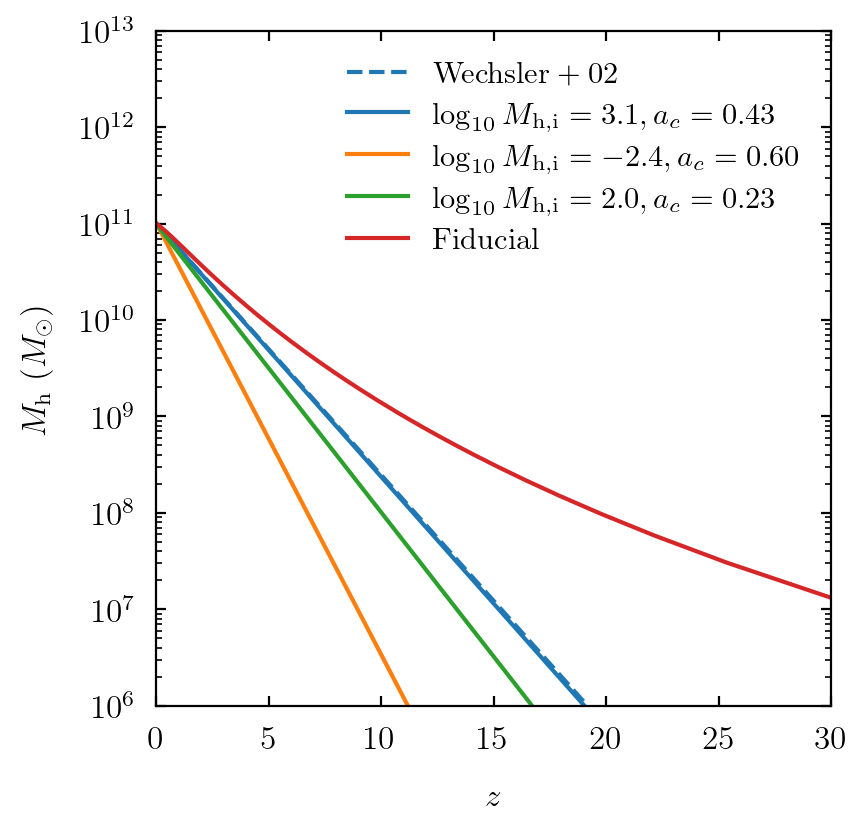

In [202]:
plotModelMAH(dic_wech, dic_fid)

In [248]:
#Plot halo with ac+1sigma, ac-1sig, mean, fid
def plotModelMAH_hilo(hi_model, lo_model, mean_model, dic_fid):
    halomass = 1e12

    plt.figure()
    plt.yscale('log')
    plt.xlabel(r'$z$')
    plt.ylabel(r'$M_{\rm h}\ (M_\odot)$')
    plt.xlim(0.0, dic_fid['models'][0].z_ini)
    plt.ylim(1E6, 1E13)

    models_list = [dic_fid,lo_model,mean_model,hi_model]
    endmass_arrs = [endmasses_fid,endmasses_lo,endmasses_mean,endmasses_hi]
    for i in range(len(models_list)):
        ind = np.argsort(np.abs(endmass_arrs[i] - halomass))[0]
        Mz = models_list[i]['Mx'][ind][models.IH]
        z = models_list[i]['z']
        
        if i==0:
            label = "Fiducial"

        elif i==1:
            label = r'$\log_{10} M_{\rm h,i} = %.1f , a_c = %.2f$' % (np.log10(Mz[0]), mu-sig)

        elif i==2:
            label = r'$\log_{10} M_{\rm h,i} = %.1f , a_c = %.2f$' % (np.log10(Mz[0]), mu)

        elif i==3:
            label = r'$\log_{10} M_{\rm h,i} = %.1f , a_c = %.2f$' % (np.log10(Mz[0]), mu+sig)

        plt.plot(z, Mz, label = label) #r'$\log_{10} M_{\rm h,0} = %.1f$' % (np.log10(Mz[-1]))
  


    plt.legend()
    plt.show()

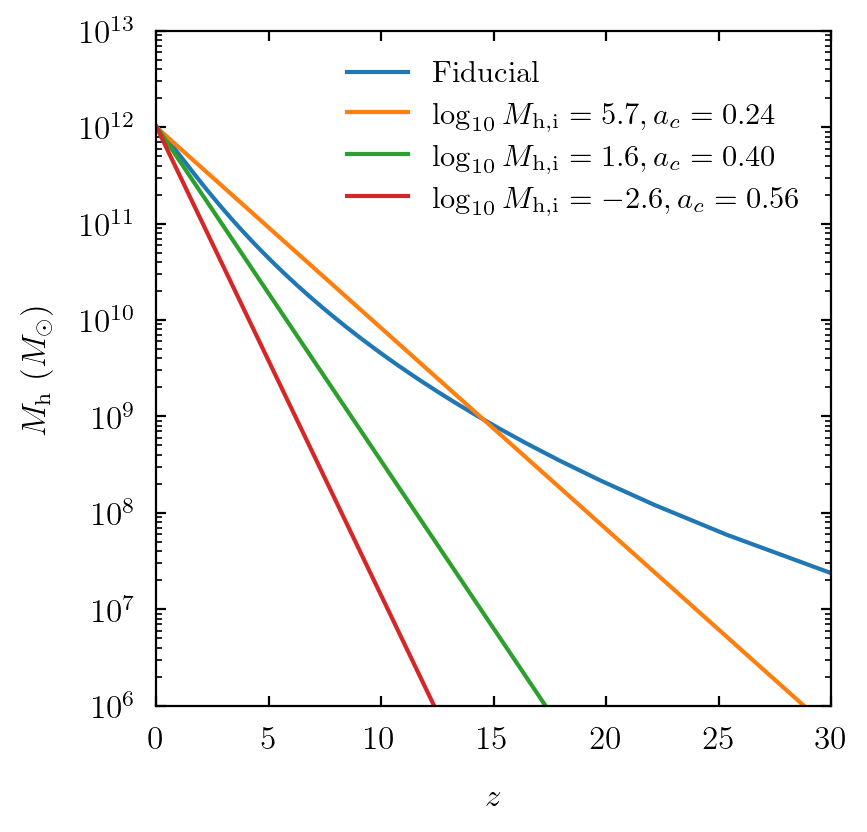

In [249]:
plotModelMAH_hilo(dic_wech_hi,dic_wech_lo,dic_wech_mean,dic_fid)

#### All components

Let's plot the time evolution of all model components for a few representative mass bins. We show both the masses as a function of time and their rates of change.

In [250]:
def plotModelHistories(dic_model, fid_model=None, save_plots=False):

    #idxs = [0, n_M // 2, int(n_M * 0.8), -1]
    idx9 = np.argmin(np.abs(endmasses - 1e9))  #np.where((endmasses>1e9) & (endmasses<1.1e9))[0][0]
    idx11 = np.argmin(np.abs(endmasses - 1e11)) #np.where((endmasses>1e11) & (endmasses<1.1e11))[0][0]
    idx13 = np.argmin(np.abs(endmasses - 1e13))  #np.where((endmasses>1e13) & (endmasses<1.1e13))[0][0]
    idx15 = np.argmin(np.abs(endmasses - 1e15))  #np.where((endmasses>1e15) & (endmasses<1.1e15))[0][0]
    print(idx9,idx11,idx13,idx15)
    idxs = [idx9,idx11,idx13,idx15]
    n_halos = len(idxs)

    if fid_model!=None:
        endmasses_fid = dic_fid['Mx'][:,models.IH,-1]
        #Indices for fiducial model
        idxfid9 = np.argmin(np.abs(endmasses_fid - 1e9))   #np.where((endmasses_fid>1e9) & (endmasses_fid<1.1e9))[0][0]
        idxfid11 = np.argmin(np.abs(endmasses_fid - 1e11)) #np.where((endmasses_fid>1e11) & (endmasses_fid<1.1e11))[0][0]
        idxfid13 = np.argmin(np.abs(endmasses_fid - 1e13)) #np.where((endmasses_fid>1e13) & (endmasses_fid<1.1e13))[0][0]
        idxfid15 = np.argmin(np.abs(endmasses_fid - 1e15)) #np.where((endmasses_fid>1e15) & (endmasses_fid<1.1e15))[0][0]
        idxs_fid = [idxfid9, idxfid11, idxfid13, idxfid15]

    t = dic_model['t']
    model_0 = dic_model['models'][0]
    Mx = dic_model['Mx']
    dMx = dic_model['dMx']

    fig, ax = plt.subplots(2, n_halos, figsize = (10, 5))
    plt.subplots_adjust(hspace = 0.1, wspace = 0.1)

    cmap = mpl.colormaps['tab10']
    colors = cmap(np.linspace(0,1,10))

    for i in range(len(idxs)):
        idx = idxs[i]

        for j in range(2):
            plt.sca(ax[j, i])
            plt.loglog()
            plt.xlim(t[0], t[-1])
            if j == 0:
                ax[j, i].set_xticklabels([])
                if i == 0:
                    plt.ylabel(r'$M_{\rm X} / M_{\rm h,0}$')
                else:
                    ax[j, i].set_yticklabels([])
                plt.ylim(2E-9, 4.0)
            else:
                plt.xlabel(r'$t\ ({\rm Gyr})$')
                if i == 0:
                    plt.ylabel(r'${\rm d} M_{\rm X} / {\rm d}t / M_{\rm h,0}\ ({\rm Gyr}^{-1})$')
                else:
                    ax[j, i].set_yticklabels([])
                plt.ylim(1E-9, 2.0)
            plt.xlim(t[0], t[-1])
            plt.axvline(cmn.cosmo.age(model_0.z_reion), ls = ':', color = 'gray', lw = 0.5)

        plt.sca(ax[0, i])
        Mh_0 = Mx[idx, models.IH, -1]
        plt.plot(t, Mx[idx, models.IH, :] / Mh_0, label = r'$\mathrm{Halo}$',c=colors[0])
        plt.plot(t, Mx[idx, models.IG, :] / Mh_0, label = r'$\mathrm{Gas}$',c=colors[1])
        plt.plot(t, Mx[idx, models.IS, :] / Mh_0, label = r'$\mathrm{Stars}$',c=colors[2])
        plt.plot(t, Mx[idx, models.IZ, :] / Mh_0, label = r'$\mathrm{Metals}$',c=colors[3])

        plt.sca(ax[1, i])
        plt.plot(t, dMx[idx, models.IH, :] / Mh_0,c=colors[0])
        plt.plot(t, dMx[idx, models.IG, :] / Mh_0,c=colors[1])
        plt.plot(t, dMx[idx, models.IS, :] / Mh_0,c=colors[2])
        plt.plot(t, dMx[idx, models.IZ, :] / Mh_0,c=colors[3])

        if fid_model!=None:
            idx_fid = idxs_fid[i]
            t_fid = fid_model['t']
            model_0_fid = fid_model['models'][0]
            Mx_fid = fid_model['Mx']
            dMx_fid = fid_model['dMx']

            plt.sca(ax[0, i])
            Mh_0_fid = Mx_fid[idx_fid, models.IH, -1]
            a = 0.8
            plt.plot(t, Mx_fid[idx_fid, models.IH, :] / Mh_0_fid, ls='--',c=colors[0], alpha=a,label="Fiducial")
            plt.plot(t, Mx_fid[idx_fid, models.IG, :] / Mh_0_fid,ls='--',c=colors[1], alpha=a)
            plt.plot(t, Mx_fid[idx_fid, models.IS, :] / Mh_0_fid,ls='--',c=colors[2], alpha=a)
            plt.plot(t, Mx_fid[idx_fid, models.IZ, :] / Mh_0_fid,ls='--',c=colors[3], alpha=a)

            plt.sca(ax[1, i])
            plt.plot(t, dMx_fid[idx_fid, models.IH, :] / Mh_0_fid,ls='--',c=colors[0], alpha=a)
            plt.plot(t, dMx_fid[idx_fid, models.IG, :] / Mh_0_fid,ls='--',c=colors[1], alpha=a)
            plt.plot(t, dMx_fid[idx_fid, models.IS, :] / Mh_0_fid,ls='--',c=colors[2], alpha=a)
            plt.plot(t, dMx_fid[idx_fid, models.IZ, :] / Mh_0_fid,ls='--',c=colors[3], alpha=a)

            plt.sca(ax[0, i])
            #plt.text(0.05, 0.8, r'Fid: $\log_{10} M_0 = %.1f$' % (np.log10(Mh_0_fid)), transform = plt.gca().transAxes)

        plt.sca(ax[0, i])
        plt.text(0.05, 0.9, r'$\log_{10} M_0 \approx %.1f$' % (np.log10(Mh_0)), transform = plt.gca().transAxes)

        if i == 1:
            plt.legend(loc = 4, frameon = True, labelspacing = 0.1)
    if save_plots==True:
        plt.savefig('sam_histories.pdf')
    else:
        plt.show()

789 1112 1371 1584


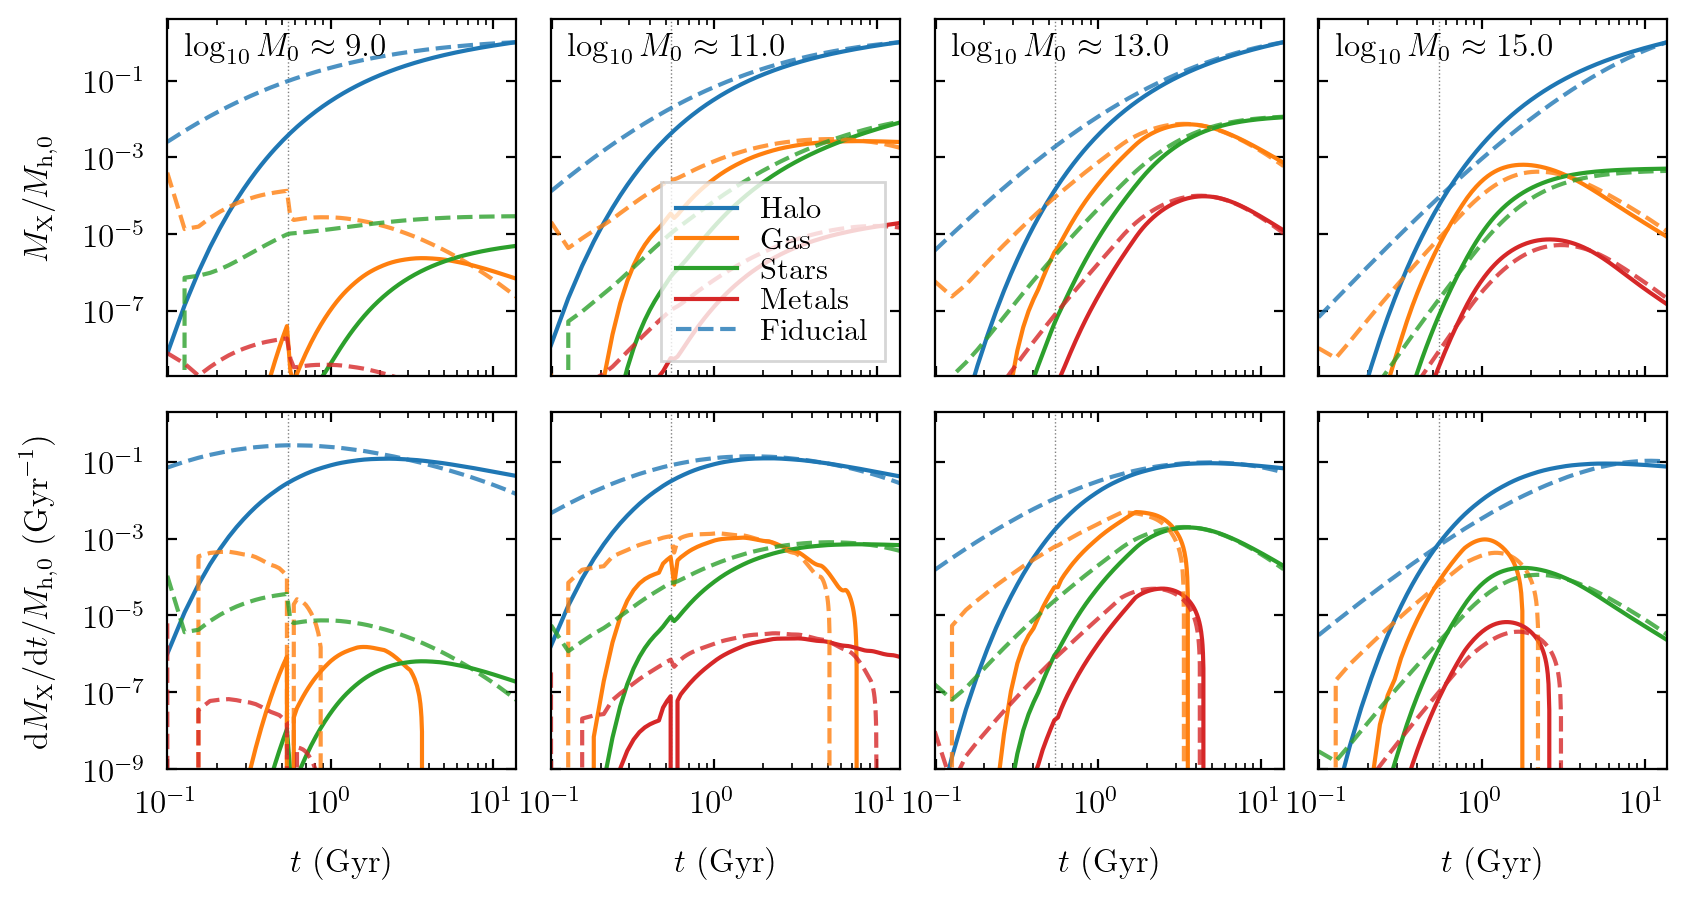

In [251]:
plotModelHistories(dic_wech,fid_model=dic_fid)

The DM accretion histories (blue) are smooth as given by the fitting function. The other components show a clear break at the redshift of reionization, where gas accretion and the SFR plummet to zero in the smallest halos. The smallest halo mass happens to lie very close to the threshold at reionization, which leads to a double-peaked gas accretion history (more below). The rates in larger halos recover but eventually begin declining as gas accretion becomes less efficient.

### Comparison to observations

We will compare our model (and its variations) to a few key benchmarks, namely
* The stellar mass-halo mass relation (SHMR) at $z = 0$ as parameterized by [Behroozi et al. 2013](https://ui.adsabs.harvard.edu/abs/2013ApJ...770...57B/abstract), [Kravtsov et al. 2018](https://ui.adsabs.harvard.edu/abs/2018AstL...44....8K/abstract), and [Munshi et al. 2021](https://ui.adsabs.harvard.edu/abs/2021ApJ...923...35M/abstract). These works cover different mass ranges and the differences between them guide us as to some residual observational uncertainties.
* The cosmic star formation density (SFRD) history as summarized by [Madau & Dickinson 2014](https://ui.adsabs.harvard.edu/abs/2014ARA%26A..52..415M/abstract).
* The mass-metallicity relation at $z = 0$ according to [Tremonti et al. 2004](https://ui.adsabs.harvard.edu/abs/2004ApJ...613..898T/abstract) and [Berg et al. 2012](https://ui.adsabs.harvard.edu/abs/2012ApJ...754...98B/abstract).

We need to renormalize the SFRD because the fitting function for the SFRD leads to $\sim 4$ times more total stellar mass at $z = 0$ than the models for the SHMR. Part of this difference comes from the difference between stellar mass created initially and stars remaining after mass return to the ISM, but even after correcting for this factor, a significant difference remains. Thus, our model cannot possibly match both sets of observations. 

We begin by computing the normalizations for each model, i.e., the total stellar density at $z = 0$. To do this, we need one additional piece of information because our model tells us how many stars there are in halos of a given mass, but not *how many* halos of that mass there are in a given cosmic volume. Thus, we need to convolve the stellar masses for each halo mass with the halo mass function, for which we assume the model of [Despali et al. 2016](https://ui.adsabs.harvard.edu/abs/2016MNRAS.456.2486D/abstract).

In [113]:
from colossus.lss import mass_function

def sfrdMadau(z):
    
    return 0.015 * (1.0 + z)**2.7 / (1.0 + ((1.0 + z) / 2.9)**5.6) * 1E9

def sfrdMadauTime(t):
    
    z = cmn.cosmo.age(t, inverse = True)
    
    return sfrdMadau(z)

def integrandSHMR(lnM, model, table_ln_Mh, table_ln_Ms):
    
    M = np.exp(lnM)
    M_h = M * h
    mfunc = mass_function.massFunction(M_h, 0.0, q_in = 'M', q_out = 'dndlnM', model = 'despali16', mdef = 'vir')
    mfunc *= h**3
    if model == 'behroozi13':
        mstar = theory.mstarBehroozi13(M, 0.0)
    elif model == 'kravtsov18':
        mstar = theory.mstarKravtsov18(M, scatter = False)
    elif model == 'table':
        mstar = np.exp(np.interp(lnM, table_ln_Mh, table_ln_Ms))
    else:
        raise Exception('Unknown model, %s' % (model))
    
    return mfunc * mstar

h = cmn.cosmo.h

# Integrate the Madau & Dickinson function over time to find the stellar density at z = 0
t1 = cmn.cosmo.age(15.0)
t2 = cmn.cosmo.age(0.0)
rho_star_madau, _ = scipy.integrate.quad(sfrdMadauTime, t1, t2, epsrel = 1E-4)

# Integrate the Behroozi function times mass function at z = 0
M0 = 1E6
M1 = 5E15
args = ('behroozi13', None, None)
rho_star_beh, _ = scipy.integrate.quad(integrandSHMR, np.log(M0), np.log(M1), args = args, epsrel = 1E-4)
args = ('kravtsov18', None, None)
rho_star_kra, _ = scipy.integrate.quad(integrandSHMR, np.log(M0), np.log(M1), args = args, epsrel = 1E-4)

# Integrate the SHMR predicted by our model
Mx_ = dic_fid['Mx']
Mh_ = Mx_[:, models.IH, -1]
Ms_ = Mx_[:, models.IS, -1]
args = ('table', np.log(Mh_), np.log(Ms_))
rho_star_model_shmr, _ = scipy.integrate.quad(integrandSHMR, np.log(Mh_[0]), np.log(Mh_[-1]), args = args, epsrel = 1E-4)

# Print results
print('Total log10 of stellar density in Msun / Mpc^3 at z = 0:')
print('SFRD (Madau & Dickinson): %.2f' % (np.log10(rho_star_madau)))
print('SHMR (Behroozi):          %.2f' % (np.log10(rho_star_beh)))
print('SHMR (Kravtsov):          %.2f' % (np.log10(rho_star_kra)))
print('SHMR (Our model):         %.2f' % (np.log10(rho_star_model_shmr)))

Total log10 of stellar density in Msun / Mpc^3 at z = 0:
SFRD (Madau & Dickinson): 8.91
SHMR (Behroozi):          8.25
SHMR (Kravtsov):          8.50
SHMR (Our model):         8.31


/Users/Sophieslaptop/Documents/Grad_school/galaxies/routines_local/theory.py:117: RuntimeWarning: overflow encountered in exp
  f = -np.log10(10**(alpha * x) + 1.0) + delta * (np.log10(1.0 + np.exp(x)))**gamma / (1.0 + np.exp(10**(-x)))
/Users/Sophieslaptop/Documents/Grad_school/galaxies/routines_local/theory.py:163: RuntimeWarning: overflow encountered in exp
  t3 = 1.0 + np.exp(10**(-x))


To make the SFRD and SHMR models compatible, we choose to renormalize the SFRD to a lower final density (more below).

We also need to compute the SFRD history of our models by summing over the SFRs at each halo mass. We again do this by convolving with the halo mass function. However, there is a choice we need to make: we can assume the mass evolution given by our model, i.e., by the fitting function for the halo accretion rate. In that case, we compute the mass function once at $z = 0$ and assume that the density of halos in each mass bin stayed fixed. In other words, halos evolve along the mass trajectories prescribed by the model. Alternatively, we can evaluate the halo mass function (according to some model) at each redshift, thus adding information about the "true" evolution of halo masses from $N$-body simulations. We implement both options, the former is chosen if ``use_model_halo_evo == True``.

We could numerically integrate similarly to the function above, but a simple sum over bins turns out to be virtually as accurate and much faster. We only use every 10th redshift bin to save time.

In [114]:
def computeSFRD(model_dic, use_model_halo_evo = True):

    zs = model_dic['z']
    Mx = model_dic['Mx']
    dMx = model_dic['dMx']
    
    idxs_plot = np.arange(len(zs))
    idxs_plot = idxs_plot[::10]
    idxs_plot = np.concatenate((idxs_plot, [len(zs) - 1]))
    mask = (zs[idxs_plot] < 8)
    idxs_plot = idxs_plot[mask]
    zs_plot = zs[idxs_plot]

    # Pre-compute the mass function at z = 0 once and use it at all redshifts if we are assuming the model
    # halo mass evolution. The mass function is in units of dN / dln(M) (Mpc^-3), so we multiply with the 
    # width of bins in ln(M) space.
    if use_model_halo_evo:
        Mh_0 = Mx[:, models.IH, -1]
        mfunc = mass_function.massFunction(Mh_0 * h, 0.0, q_in = 'M', q_out = 'dndlnM', model = 'despali16', 
                                           mdef = 'vir') * h**3
        ln_M_centers = np.log(Mh_0)
        ln_M_edges = 0.5 * (ln_M_centers[1:] + ln_M_centers[:-1])
        ln_M_edges = np.concatenate((np.array([ln_M_centers[0]]), ln_M_edges, np.array([ln_M_centers[-1]])))
        dlnM0 = np.diff(ln_M_edges)
        mfunc_dlnM0 = mfunc * dlnM0

    sfr_tot = np.zeros_like(idxs_plot, float)
    for i in range(len(idxs_plot)):

        idx = idxs_plot[i]
        z = zs_plot[i]
        dMs = dMx[:, models.IS, idx]

        if use_model_halo_evo:
            mfunc_dlnM = mfunc_dlnM0
        else:
            Mh_z = Mx[:, models.IH, idx]
            mfunc = mass_function.massFunction(Mh_z * h, z, q_in = 'M', q_out = 'dndlnM', model = 'despali16', 
                                           mdef = 'vir') * h**3
            ln_M_centers = np.log(Mh_z)
            ln_M_edges = 0.5 * (ln_M_centers[1:] + ln_M_centers[:-1])
            ln_M_edges = np.concatenate((np.array([ln_M_centers[0]]), ln_M_edges, np.array([ln_M_centers[-1]])))
            dlnM = np.diff(ln_M_edges)
            mfunc_dlnM = mfunc * dlnM

        # "Integrate" by bins, returning the SFRD in Msun/yr/Mpc^3. Note that dMs_dt already includes 
        # the (1 - R) factor, i.e., refers to the eventual mass of stars remaining. 
        sfr_tot[i] = np.sum(dMs * mfunc_dlnM)

    return zs_plot, sfr_tot

In [115]:
sfrd_z, sfrd_model_mfuncevo = computeSFRD(dic_fid, use_model_halo_evo = False)
_,      sfrd_model_haloevo  = computeSFRD(dic_fid, use_model_halo_evo = True)

We can now perform a sanity check: integrating the SFRD of our model over time should give (almost) the same total stellar density as integrating the SHMR at $z = 0$. We repeat this calculation for both versions of the SFRD history.

In [116]:
def integrandSFRD(t, table_t, table_sfrd):
    
    return np.interp(t, table_t, table_sfrd)

ts = cmn.cosmo.age(sfrd_z)
t0 = ts[0]
t1 = ts[-1]
args = (ts, sfrd_model_mfuncevo)
rho_star_model_sfrd_mfuncevo, _ = scipy.integrate.quad(integrandSFRD, t0, t1, args = args, epsrel = 1E-4)
args = (ts, sfrd_model_haloevo)
rho_star_model_sfrd_haloevo, _ = scipy.integrate.quad(integrandSFRD, t0, t1, args = args, epsrel = 1E-4)

print('With mass function evolution according to mass function model (N-body simulations):')
print('SFRD:                                %.2f' % (np.log10(rho_star_model_sfrd_mfuncevo)))
print('Ratio to integrated SHMR at z = 0:   %.3f' % (rho_star_model_shmr / rho_star_model_sfrd_mfuncevo))
print('')
print('With mass function evolution according to our halo histories:')
print('SFRD:                                %.2f' % (np.log10(rho_star_model_sfrd_haloevo)))
print('Ratio to integrated SHMR at z = 0:   %.3f' % (rho_star_model_shmr / rho_star_model_sfrd_haloevo))

With mass function evolution according to mass function model (N-body simulations):
SFRD:                                8.57
Ratio to integrated SHMR at z = 0:   0.539

With mass function evolution according to our halo histories:
SFRD:                                8.31
Ratio to integrated SHMR at z = 0:   1.001


The agreement depends on the ``use_model_halo_evo`` parameter in the expected way: if we use our model histories to evolve the mass function (assuming that the number density of halos stays the same), the model is self-consistent in the sense that the integrals over the SFRD and SHMR agree. When using the more realistic evolution of the mass function from $N$-body simulations, there is no reason why the two have to agree any longer, and in fact they deviate by a factor of about two. One important reason for this disagreement are mergers: when halos merge with each other, we cannot think of the evolution of the mass function as just growth of halos at fixed number densities.

Returning to the normalization of the SFRD, we renormalize the Madau & Dickinson formula and plot the range between the total stellar densities corresponding to the Behroozi and Kravtsov SHMR models. There is one more complication: we need to fold in the mass return rate, which means that the stars formed (the SFR) is not the same as the stars remaining (which the stellar mass variable in our model describes). Thus, we divide our model SFRD by $(1 - {\cal R})$.

In [252]:
from matplotlib.ticker import LogLocator

Mmin_shmr = 1E8
Mmax_shmr = 1.2E15
zmax = 8.0
R_loss_def = 0.46

# Behroozi+2013 SHMR
Mvir_beh = 10**np.linspace(np.log10(1e9), np.log10(Mmax_shmr), 200)
mstar_beh = theory.mstarBehroozi13(Mvir_beh, 0.0)
mask = (mstar_beh >= 10**7.25)
Mvir_beh = Mvir_beh[mask]
mstar_beh = mstar_beh[mask]

# Kravtsov+2018
Mvir_kra = 10**np.linspace(10.0, 15.2, 200)
mstar_kra = theory.mstarKravtsov18(Mvir_kra, scatter = True)

# Munshi+2021
Mh_crit = 1E10
norm = 1E7
Mvir_mun = 10**np.linspace(7.0, 11.0, 50)
mstar_mun = np.zeros_like(Mvir_mun)
scatter_mun = np.zeros_like(Mvir_mun)
mask = (Mvir_mun > Mh_crit)
mstar_mun[mask] = norm * (Mvir_mun[mask] / Mh_crit)**1.9
scatter_mun[mask] = 0.3
mask = np.logical_not(mask)
mstar_mun[mask] = norm * (Mvir_mun[mask] / Mh_crit)**2.81
scatter_mun[mask] = 0.3 - 0.39 * (np.log10(Mvir_mun[mask]) - 10.0)
y_mun = mstar_mun / Mvir_mun / fb
y_mun_lo = y_mun / 10**scatter_mun
y_mun_hi = y_mun * 10**scatter_mun

# Renormalize Madau curves
log_z1_min = 0.0
log_z1_max = np.log10(1.0 + zmax)
log_z1_plot = np.linspace(log_z1_min, log_z1_max, 50)
z_plot = 10**log_z1_plot - 1.0
sfrd_madau_ori = sfrdMadau(z_plot)
sfrd_madau_beh = sfrd_madau_ori * rho_star_beh / rho_star_madau / (1.0 - R_loss_def)
sfrd_madau_kra = sfrd_madau_ori * rho_star_kra / rho_star_madau / (1.0 - R_loss_def)

# Tremonti et al. 2004
log_Ms_tremonti = np.linspace(8.5, 11.5, 50)
log_OH_tremonti = -1.492 + 1.847 * log_Ms_tremonti - 0.08026 * log_Ms_tremonti**2
Z_tremonti = 10**(log_OH_tremonti - cmn.LOG_OH_SOLAR)
Z_tremonti_lo = Z_tremonti / 10**0.1
Z_tremonti_hi = Z_tremonti * 10**0.1

# Berg et al. 2012
log_Ms_berg = np.linspace(5.0, 10.0, 50)
log_OH_berg = 5.61 + 0.29 * log_Ms_berg
Z_berg = 10**(log_OH_berg - cmn.LOG_OH_SOLAR)
Z_berg_lo = Z_berg / 10**0.15
Z_berg_hi = Z_berg * 10**0.15

def plotModels(model_dics, labels, show_all_labels = False, shmr_y_max = 7E-1, use_model_halo_evo = True,
              mz_y_max = 5E0, save = False, fn_out = 'sam_results.pdf'):

    fig, ax = plt.subplots(1, 3, figsize = (11, 3.1))
    plt.subplots_adjust(hspace = 0.1, wspace = 0.35)

    # Prepare SHMR plot
    plt.sca(ax[0])
    plt.loglog()
    plt.xlim(Mmin_shmr, Mmax_shmr)
    plt.ylim(3E-5, shmr_y_max)
    plt.xlabel(r'$M_{\rm vir}\ (M_\odot)$')
    plt.ylabel(r'$M_\ast / M_{\rm vir} / f_{\rm b}$', labelpad = 5)
    plt.gca().xaxis.set_major_locator(LogLocator(numticks = 100))
    plt.gca().xaxis.set_minor_locator(LogLocator(numticks = 100, subs = np.arange(2, 10)))
    
    # Behroozi
    if show_all_labels:
        label = r'$\mathrm{Behroozi+2013}$'
    else:
        label = None
    plt.plot(Mvir_beh, mstar_beh / Mvir_beh / fb, ls = '--', c = 'gray', label = label)

    # Kravtsov
    if show_all_labels:
        label = r'$\mathrm{Kravtsov+2018}$'
    else:
        label = None
    plt.plot(Mvir_kra, mstar_kra / Mvir_kra / fb, ls = '-.', c = 'gray', label = label)

    # Munshi
    plt.fill_between(Mvir_mun, y_mun_lo, y_mun_hi, color = 'gray', alpha = 0.2)
    if show_all_labels:
        label = r'$\mathrm{Munshi+2021}$'
    else:
        label = None
    plt.plot(Mvir_mun, y_mun, ls = ':', c = 'gray', label = label)

    # Prepare SFRD plot
    plt.sca(ax[1])
    plt.xlabel(r'$\log_{10} (1 + z)$')
    plt.ylabel(r'$\Psi\ (M_\odot / {\rm yr} / {\rm Mpc}^3)$', labelpad = 5)
    plt.yscale('log')
    plt.xlim(log_z1_min, log_z1_max)

    # Madau & Dickinson
    if show_all_labels:
        label = r'$\mathrm{MD14,\ renormalized}$'
        plt.plot(log_z1_plot, sfrd_madau_ori, color = 'gray', ls = '--', 
                 label = r'$\mathrm{MD14,\ original}$')    
    else:
        label = None
    plt.fill_between(log_z1_plot, sfrd_madau_beh, sfrd_madau_kra, color = 'gray', alpha = 0.3, label = label)

    # Prepare metallicity plot
    plt.sca(ax[2])
    plt.xlabel(r'$M_\star\ (M_\odot)$')
    plt.ylabel(r'$Z / Z_\odot$', labelpad = 5)
    plt.loglog()
    plt.xlim(5E4, 5E11)
    plt.ylim(8E-3, mz_y_max)
    plt.gca().xaxis.set_major_locator(LogLocator(numticks = 100))
    plt.gca().xaxis.set_minor_locator(LogLocator(numticks = 100, subs = np.arange(2, 10)))

    plt.fill_between(10**log_Ms_tremonti, Z_tremonti_lo, Z_tremonti_hi, color = 'gray', alpha = 0.2)
    plt.plot(10**log_Ms_tremonti, Z_tremonti, color = 'gray', ls = '-.', label = r'$\mathrm{Tremonti+2004}$')

    plt.fill_between(10**log_Ms_berg, Z_berg_lo, Z_berg_hi, color = 'gray', alpha = 0.2)
    plt.plot(10**log_Ms_berg, Z_berg, color = 'gray', ls = '--', label = r'$\mathrm{Berg+2012}$')

    # Plot models
    for i in range(len(model_dics)):
        
        Mx = model_dics[i]['Mx']
        Mh_0 = Mx[:, models.IH, -1]
        Mg_0 = Mx[:, models.IG, -1]
        Ms_0 = Mx[:, models.IS, -1]
        MZ_0 = Mx[:, models.IZ, -1]
        
        # Compute the SFRD history of our model. We increase the SFR history by a factor of 1 / (1 - R)
        # since more stars were formed than remain today, the latter being what our function returns.
        # If we are not using the model's halo mass history but a mass function fit instead, then the
        # ratio between the SFRD and the total mass implied by the SHMR today can differ quite a bit. In
        # that case, we renormalize the SFRD such that it corresponds to the same total stellar mass as 
        # the SHMR of the model today.
        sfrd_z, sfrd_model = computeSFRD(model_dics[i], use_model_halo_evo = use_model_halo_evo)
        sfrd_model /= (1.0 - R_loss_def)
        if not use_model_halo_evo:
            sfrd_model *= rho_star_model_shmr / rho_star_model_sfrd_mfuncevo
        
        if i == 0:
            #lw = 2.0
            ls = '--'
        else:
            #lw = 1.0
            ls = '-'
        
        plt.sca(ax[0])
        plt.scatter(Mh_0, Ms_0 / Mh_0 / fb,  label = labels[i],s=2,alpha=0.5)
        
        plt.sca(ax[1])
        plt.scatter(np.log10(sfrd_z + 1.0), sfrd_model, label=labels[i],s=2)

        plt.sca(ax[2])
        plt.plot(Ms_0, MZ_0 / Mg_0 / cmn.Z_SOLAR, ls=ls)

    plt.sca(ax[0]) 
    plt.legend(frameon = True, labelspacing = 0.2, loc = 4)
    if show_all_labels:
        plt.sca(ax[1]) 
        plt.legend(frameon = True, labelspacing = 0.2, loc = 8)
        plt.sca(ax[2]) 
        plt.legend(frameon = True, labelspacing = 0.2, loc = 8)
    if save:
        plt.savefig(fn_out)
    else:
        plt.show()


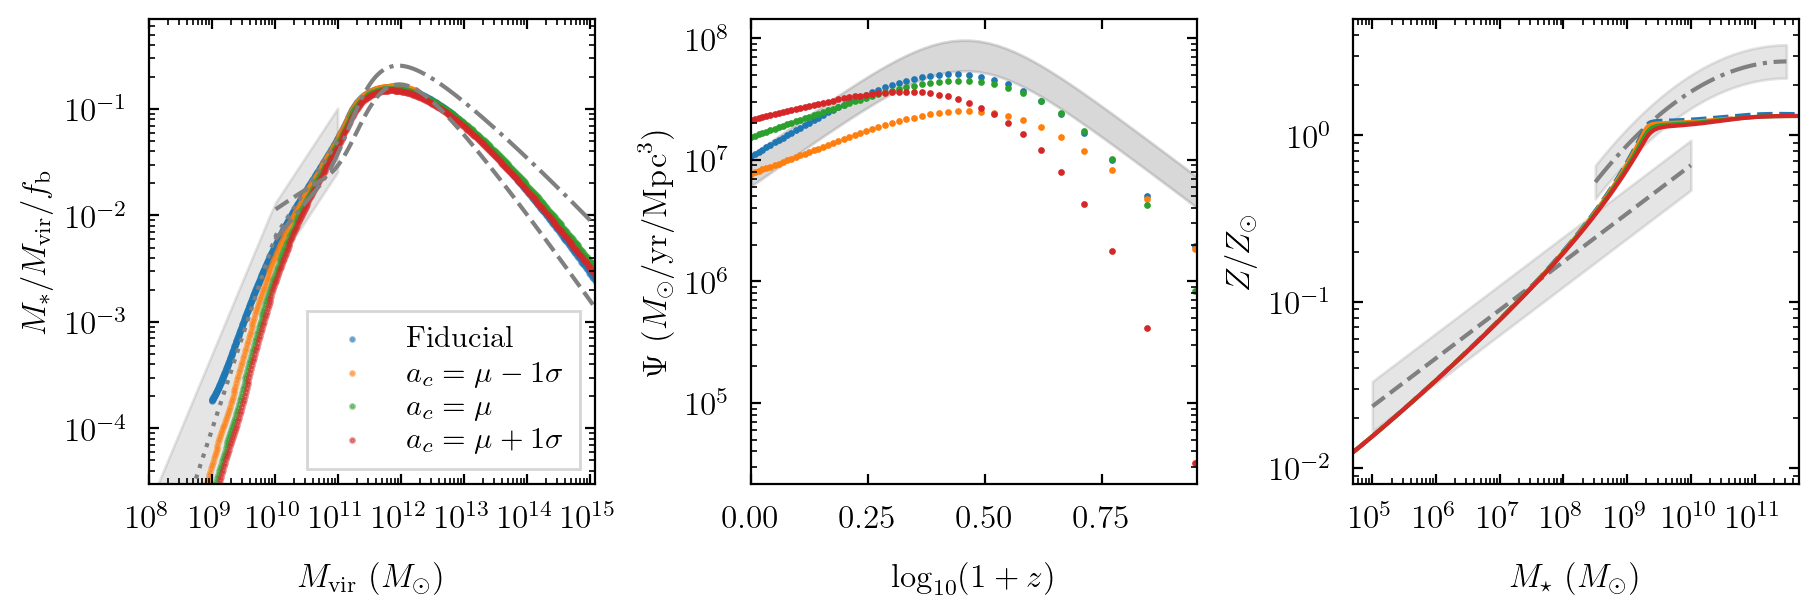

In [254]:
save_plots=False
plotModels([dic_fid, dic_wech_lo,dic_wech_mean,dic_wech_hi], \
           ["Fiducial",r'$a_c=\mu - 1\sigma$',r'$a_c=\mu$',r'$a_c=\mu + 1\sigma$'], show_all_labels = False, use_model_halo_evo = True,
          save = save_plots, fn_out = 'sam_fiducial.pdf') #dic_fid,dic_wech_lo,r'$\mathrm{Fiducial}$', r'$\mathrm{-1 \sigma}$'
#plotModels([dic_fid, dic_wech], [r'$\mathrm{Fiducial}$',"Scatter"], show_all_labels = False, use_model_halo_evo = True)

Our fiducial model matches the observational data rather well! The detailed calculation of the SFRD makes quite a bit of difference. The top row shows the version with ``use_model_halo_evo = True``, meaning that we assume that halo number densities stay the same and their mass evolves as given by our model. In the bottom row, we use the evolution of the mass function tuned to $N$-body simulations. As we saw above, the latter leads to a better fit to observations but is less internally consistent. We thus default to using the halo evolution of our model in the following plots.

### Investigating the physics

Let's deconstruct our model by starting from one that has no models for gas accretion and star formation suppression of any kind. Then we will successively improve this model and check the impact of the free parameters along the way.

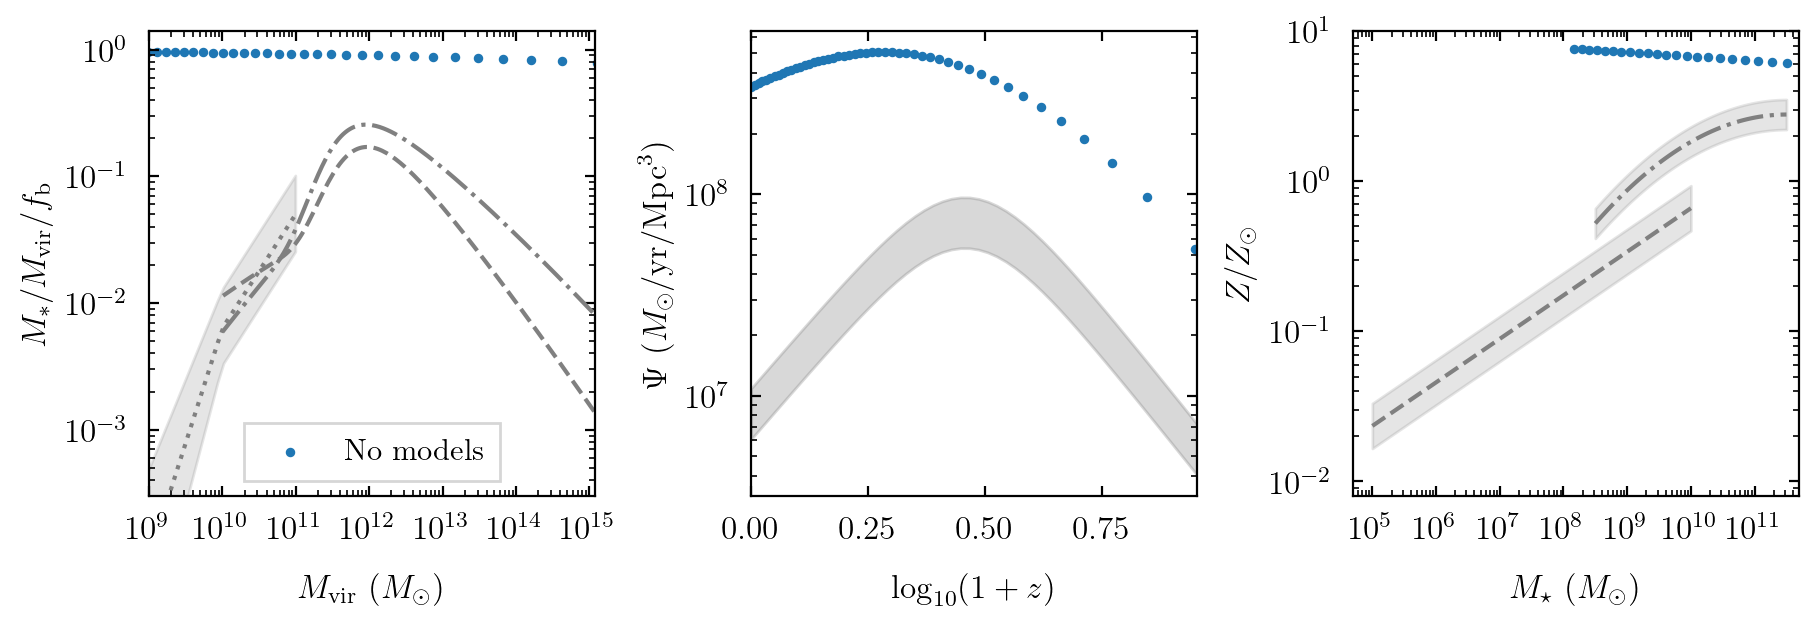

In [73]:
pars_cur = dict(model_reion = 'none', model_cooling = 'none', model_wind = 'none', R_loss = 0.0, eta_min = 0.0)
dic_cur = evaluateModel(**pars_cur)

Mx_models = [dic_cur]
labels = [r'$\mathrm{No\ models}$']
plotModels(Mx_models, labels, shmr_y_max = 1.4, mz_y_max = 1E1)

If we do not suppress gas accretion, all halos form stars at the same efficiency of unity; the slight deviations in the left panel must be numerical. The SFRD history follows the integrated mass evolution of halos in our mass range.

#### General gas accretion and cooling efficiencies

We wish to impose a lower cutoff mass due to reionization and an upper cutoff due to long cooling times. We begin by plotting the redshift evolution of the respective critical halo masses.

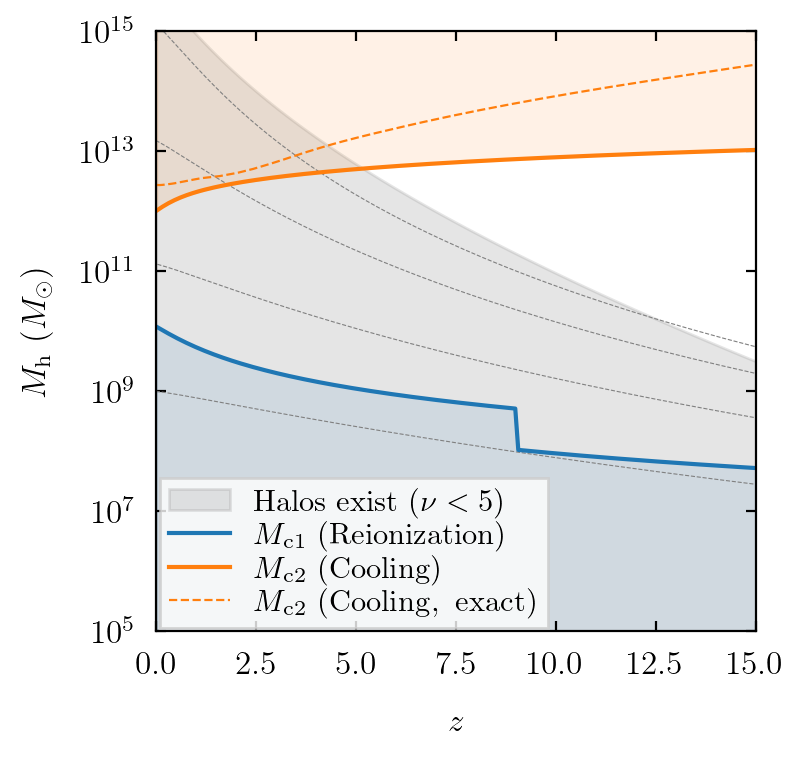

In [74]:
from colossus.lss import peaks

z = np.linspace(0.0, 15.0, 200)
n_z = len(z)
Z = 0.01

def eq(Mvir, z, Z):
    
    tcool = theory.tcoolFromMvir(Mvir, z, Z) / constants.GYR
    t = cmn.cosmo.age(z)
    
    return tcool - t

model_0 = dic_cur['models'][0]

# Approximate at which cooling becomes inefficient
M_c2 = model_0.M_c2_0 * np.sqrt(cmn.cosmo.Ez(z)) * mass_so.deltaVir(z) / mass_so.deltaVir(0.0)

# Cutoff mass due to reionization
mask = (z < model_0.z_reion)
M_c1 = np.ones_like(M_c2)
M_c1[~mask] = theory.MvirFromTvir(7000.0, z[~mask])
M_c1[mask] = theory.MvirFromTvir(20000.0, z[mask])

# Numerical version of cooling limit
Mmin_plot = 1E11
Mmax_plot = 1E15
M_equal = np.ones((n_z), float)
mask = np.ones((n_z), bool)
for i in range(n_z):
    args = (z[i], Z)
    if eq(Mmin_plot * 1.0001, *args) * eq(Mmax_plot * 0.999, *args) < 0.0:
        M_equal[i] = scipy.optimize.brentq(eq, Mmin_plot * 1.0001, Mmax_plot * 0.999, args = args)
    else:
        mask[i] = False

# Plot
plt.figure(figsize = (4.0, 4.0))
plt.xlabel(r'$z$')
plt.ylabel(r'$M_{\rm h}\ (M_\odot)$')
plt.yscale('log')
plt.xlim(z[0], z[-1])
plt.ylim(1E5, 1E15)

# Peak realistic halo mass range
M_nu_hi = peaks.massFromPeakHeight(5.0, z)
plt.fill_between(z, 0.0, M_nu_hi, interpolate = True, color = 'gray', alpha = 0.2, 
                 label = r'$\mathrm{Halos\ exist}\ (\nu < 5)$')

# Plot accretion histories of model halos
idxs = [0, n_M // 2, int(n_M * 0.8), -1]
z_model = dic_cur['z']
for idx in idxs:
    Mh = dic_cur['Mx'][idx, models.IH, :]
    plt.plot(z_model, Mh, '--', color = 'gray', lw = 0.4)

# Plot areas excluded by reionization and cooling
plt.fill_between(z, M_c1, 1E-5, interpolate = True, color = cmn.color_cycle[0], alpha = 0.1)
plt.plot(z, M_c1, color = cmn.color_cycle[0], label = r'$M_{\rm c1}\ \mathrm{(Reionization)}$')
plt.fill_between(z, M_c2, 1E20, interpolate = True, color = cmn.color_cycle[1], alpha = 0.1)
plt.plot(z, M_c2, color = cmn.color_cycle[1], label = r'$M_{\rm c2}\ \mathrm{(Cooling)}$')

# Plot exact cooling limit for comparison
plt.plot(z[mask], M_equal[mask], color = cmn.color_cycle[1], ls = '--', lw = 0.8, label = r'$M_{\rm c2}\ \mathrm{(Cooling,\ exact)}$')

plt.legend(loc = 3, frameon = True, labelspacing = 0.1, borderpad = 0.3, borderaxespad = 0.1)
if save_plots:
    plt.savefig('sam_mc_gas.pdf')
else:
    plt.show()

The gray area shows where halos can realistically exist, which highlights a small inconsistency in our model: at very early times, the most massive halos are somewhat unrealistic (gray dashed lines). This does not matter too much for the star formation predictions though.

The minimum mass due to reionization, corresponding to minimum temperatures before and after, jumps at reionization by definition. The match between the exact and approximate $M_{\rm c2}$ curves looks poor, but this limit is relevant really only at low redshift since halos this massive do not exist at high $z$ (gray curves). Let's plot the combined baryon efficiency from both factors.

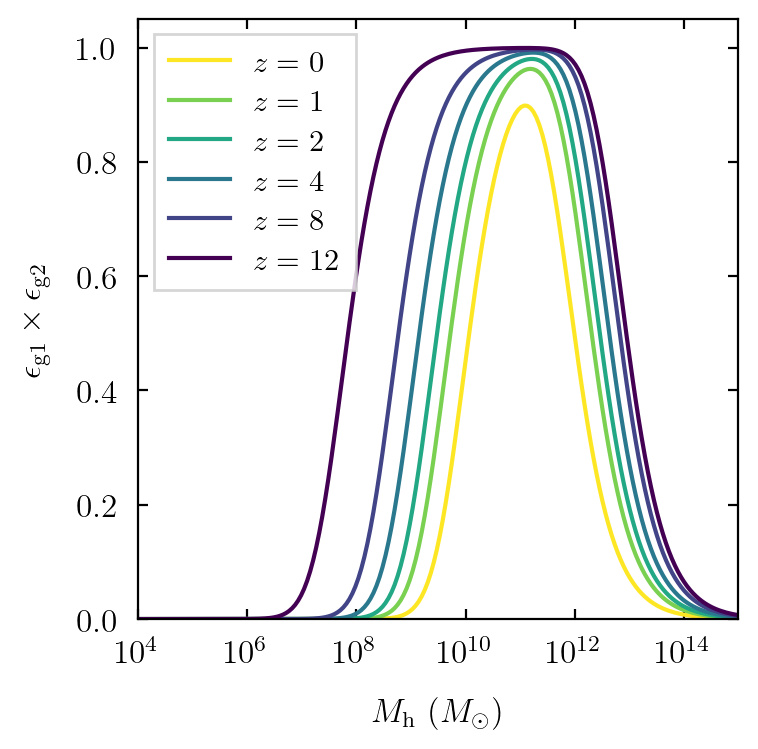

In [75]:
Mh_test = 10**np.linspace(4.0, 15.0, 200)
zs = [0, 1, 2, 4, 8, 12]
cmap = plt.get_cmap('viridis_r')
model_fid = dic_fid['models'][0]

plt.figure(figsize = (4.0, 4.0))
plt.xscale('log')
plt.xlabel(r'$M_{\rm h}\ (M_\odot)$')
plt.ylabel(r'$\epsilon_{\rm g1} \times \epsilon_{\rm g2}$')
plt.xlim(Mh_test[0], Mh_test[-1])
plt.ylim(0.0, 1.05)

for i, z in enumerate(zs):
    t = cmn.cosmo.age(z)
    total_eff = model_fid.eps_g1(t, [Mh_test]) * model_fid.eps_g2(t, [Mh_test])
    c = cmap(float(i) / (len(zs) - 1.0))
    plt.plot(Mh_test, total_eff, c = c, label = r'$z = %s$' % (str(z)))

plt.legend(frameon = True)
if save_plots:
    plt.savefig('sam_gas_eff.pdf')
else:
    plt.show()

We see how the range of halo masses where gas accretion and cooling is efficient shrinks with time. Let's plot how the two efficiency factors affect our model outputs, absent other physics.

In [76]:
pars_cur.update(dict(model_reion = 'okamoto08'))
dic_reion = evaluateModel(**pars_cur)

pars_cur.update(dict(model_cooling = 'cutoff', model_reion = 'none'))
dic_coolcut = evaluateModel(**pars_cur)

del pars_cur['model_reion']
del pars_cur['model_cooling']

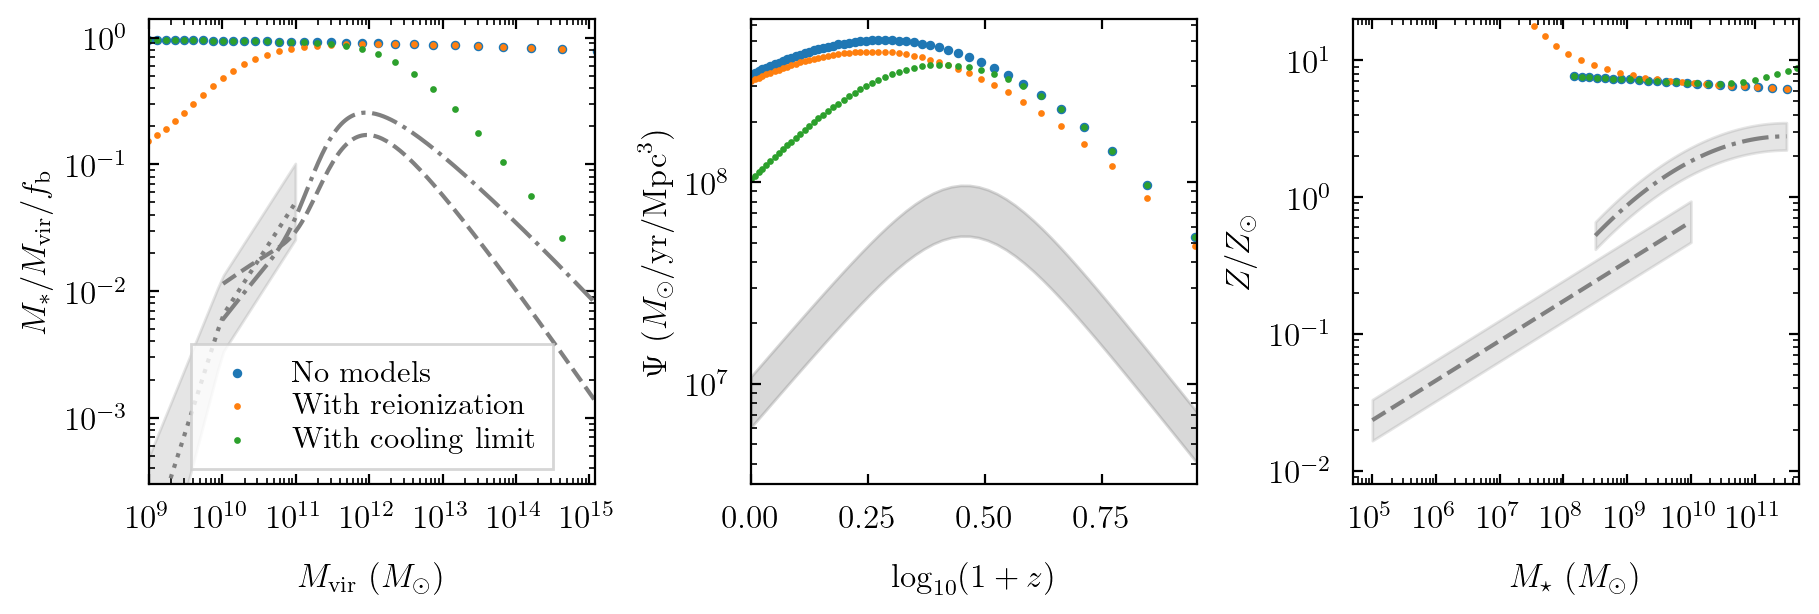

In [77]:
model_dics = [dic_cur, dic_reion, dic_coolcut]
labels = [r'$\mathrm{No\ models}$', r'$\mathrm{With\ reionization}$', r'$\mathrm{With\ cooling\ limit}$']
plotModels(model_dics, labels, shmr_y_max = 1.4, mz_y_max = 2E1)

#### Details of the reionization model

The reionization model contains a few different parameters. Let's see how each of them affects the results. First, we check how important the redshift of reionization is, given that this number is not known exactly (and that reionization did not actually happen exactly at one redshift).

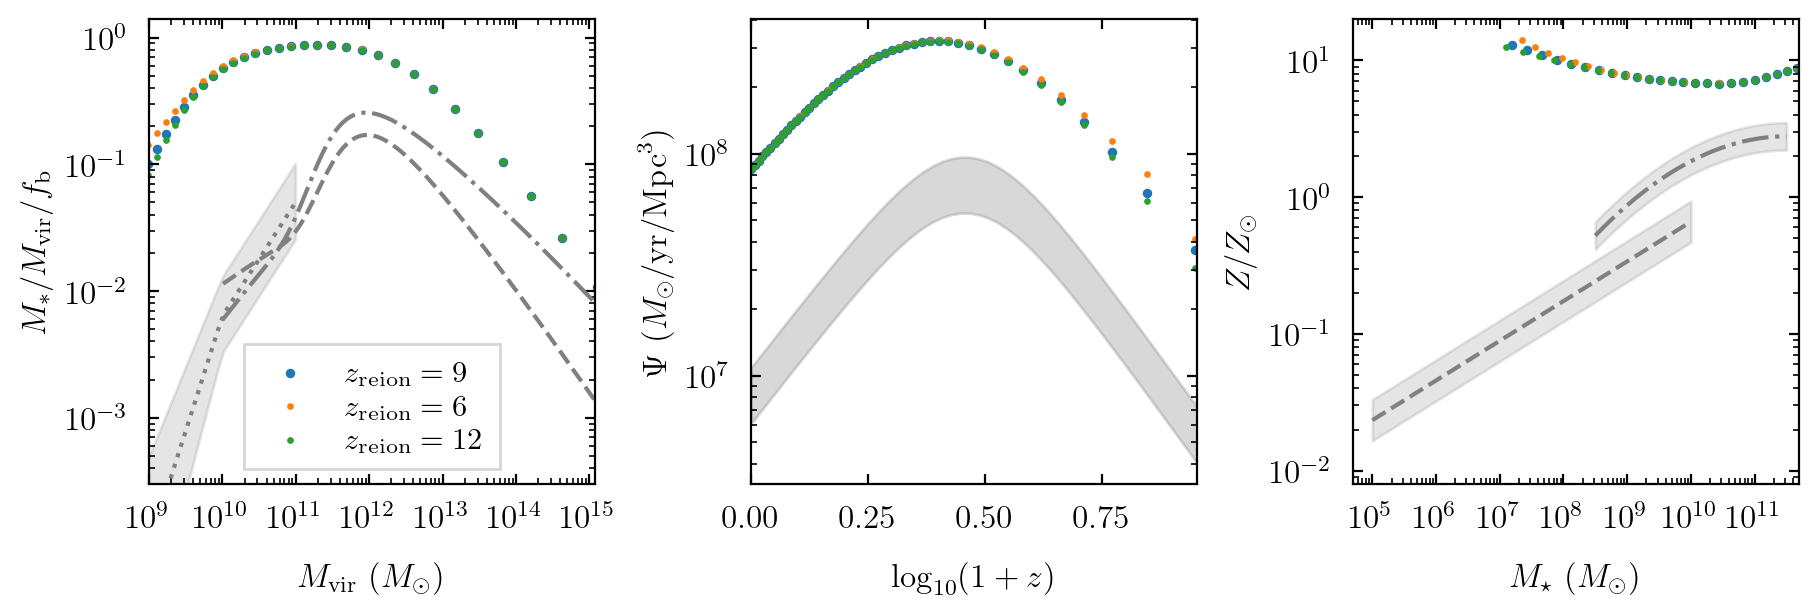

In [78]:
dic_cur = evaluateModel(**pars_cur)
dic_zreion_lo = evaluateModel(z_reion = 6.0, **pars_cur)
dic_zreion_hi = evaluateModel(z_reion = 12.0, **pars_cur)
model_dics = [dic_cur, dic_zreion_lo, dic_zreion_hi]
labels = [r'$z_{\rm reion} = 9$', r'$z_{\rm reion} = 6$', r'$z_{\rm reion} = 12$']
plotModels(model_dics, labels, shmr_y_max = 1.4, mz_y_max = 2E1)

The effect is not terribly large, although we form a few more stars in the least massive halos if reionization happens late.

We now make the same plot for the minimum temperature before reionization.

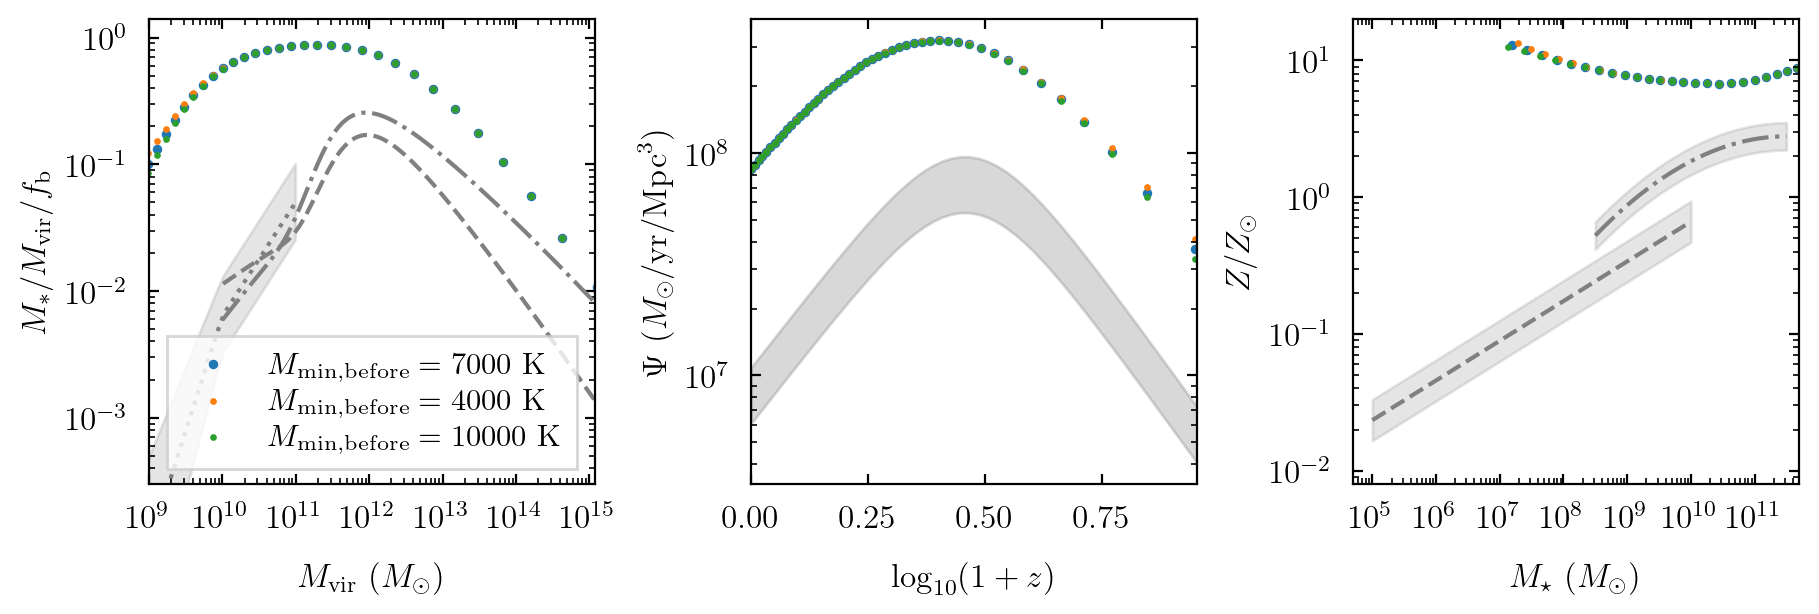

In [79]:
dic_Tmin_bef_lo = evaluateModel(T_min_before = 4000.0, **pars_cur)
dic_Tmin_bef_hi = evaluateModel(T_min_before = 10000.0, **pars_cur)
model_dics = [dic_cur, dic_Tmin_bef_lo, dic_Tmin_bef_hi]
labels = [r'$M_{\rm min,before} = 7000\ {\rm K}$', 
          r'$M_{\rm min,before} = 4000\ {\rm K}$', 
          r'$M_{\rm min,before} = 10000\ {\rm K}$']
plotModels(model_dics, labels, shmr_y_max = 1.4, mz_y_max = 2E1)

Again, not a huge effect. The same plot for the minimum temperature after reionization:

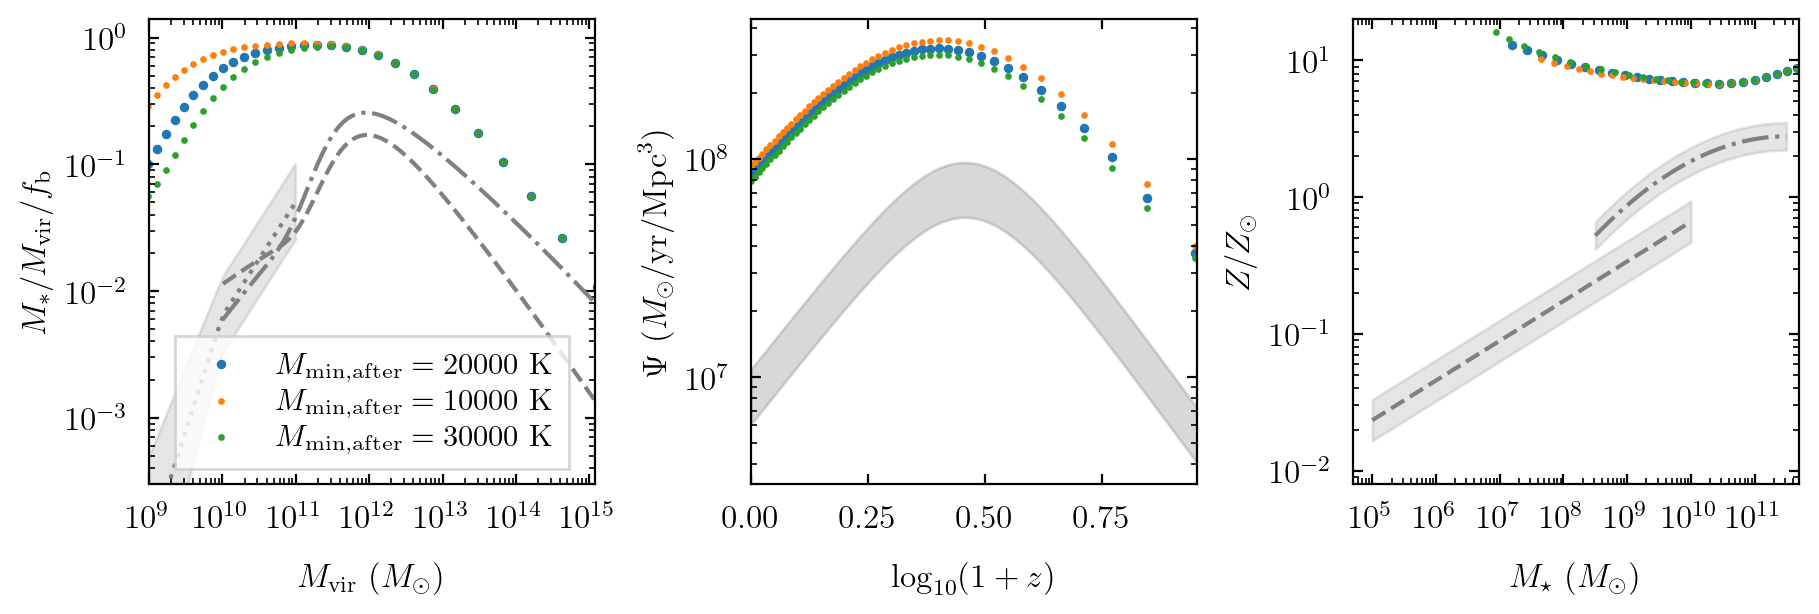

In [80]:
dic_Tmin_aft_lo = evaluateModel(T_min_after = 10000.0, **pars_cur)
dic_Tmin_aft_hi = evaluateModel(T_min_after = 30000.0, **pars_cur)
model_dics = [dic_cur, dic_Tmin_aft_lo, dic_Tmin_aft_hi]
labels = [r'$M_{\rm min,after} = 20000\ {\rm K}$', 
          r'$M_{\rm min,after} = 10000\ {\rm K}$', 
          r'$M_{\rm min,after} = 30000\ {\rm K}$']
plotModels(model_dics, labels, shmr_y_max = 1.4, mz_y_max = 2E1)

This temperature has a larger effect, especially on the SHMR. The reason is presumably that more stars are formed after $z = 9$ than before. The per-reionization limit might become important if we went down to even lower halo masses. Finally, we check the $\alpha_1$ parameter, which determines how rapidly the cutoff happens.

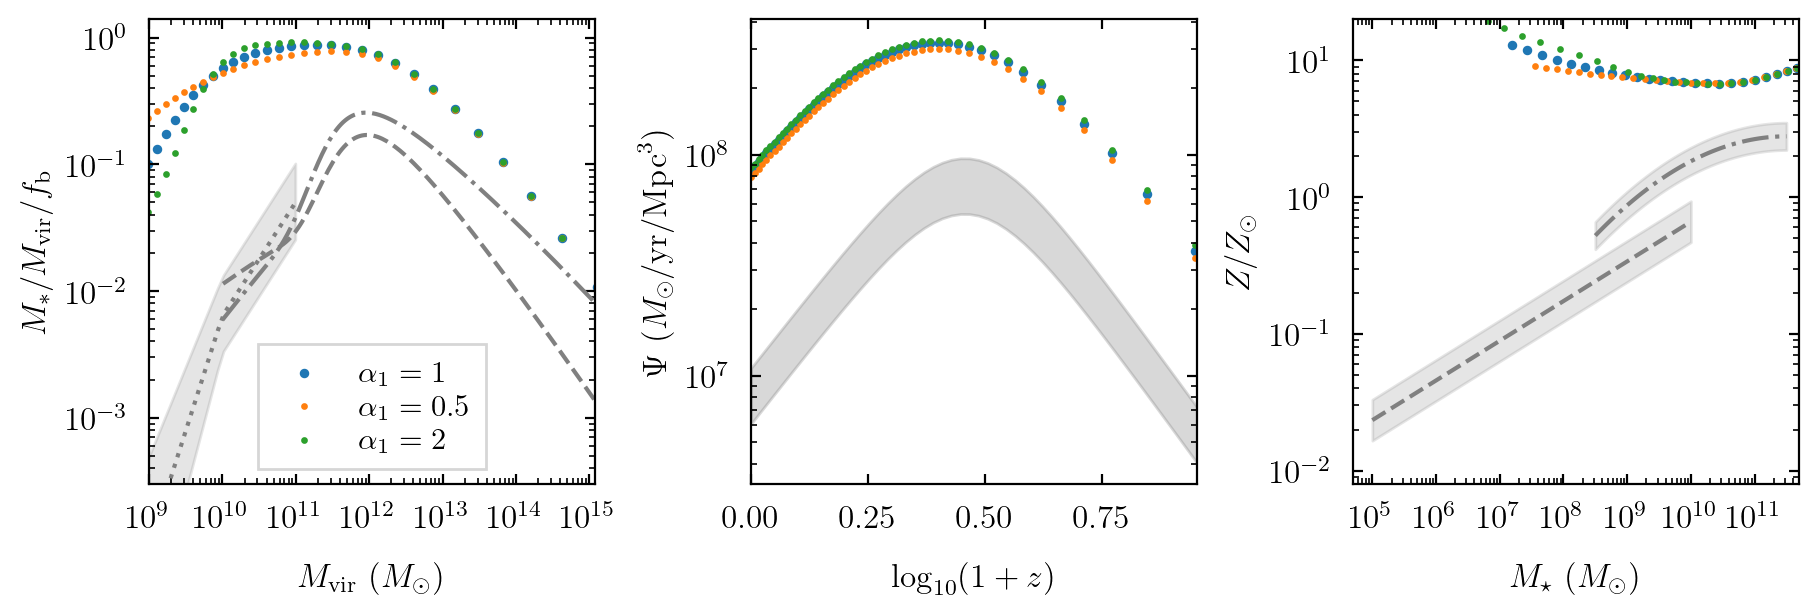

In [81]:
dic_alphareion_lo = evaluateModel(alpha1 = 0.5, **pars_cur)
dic_alphareion_hi = evaluateModel(alpha1 = 2.0, **pars_cur)
model_dics = [dic_cur, dic_alphareion_lo, dic_alphareion_hi]
labels = [r'$\alpha_1 = 1$', r'$\alpha_1 = 0.5$', r'$\alpha_1 = 2$']
plotModels(model_dics, labels, shmr_y_max = 1.4, mz_y_max = 2E1)

Again, this makes a modest difference to the slope of the SHMR at the low-mass end.

#### Details of the cooling model

Let's explore the parameters of the cooling model.

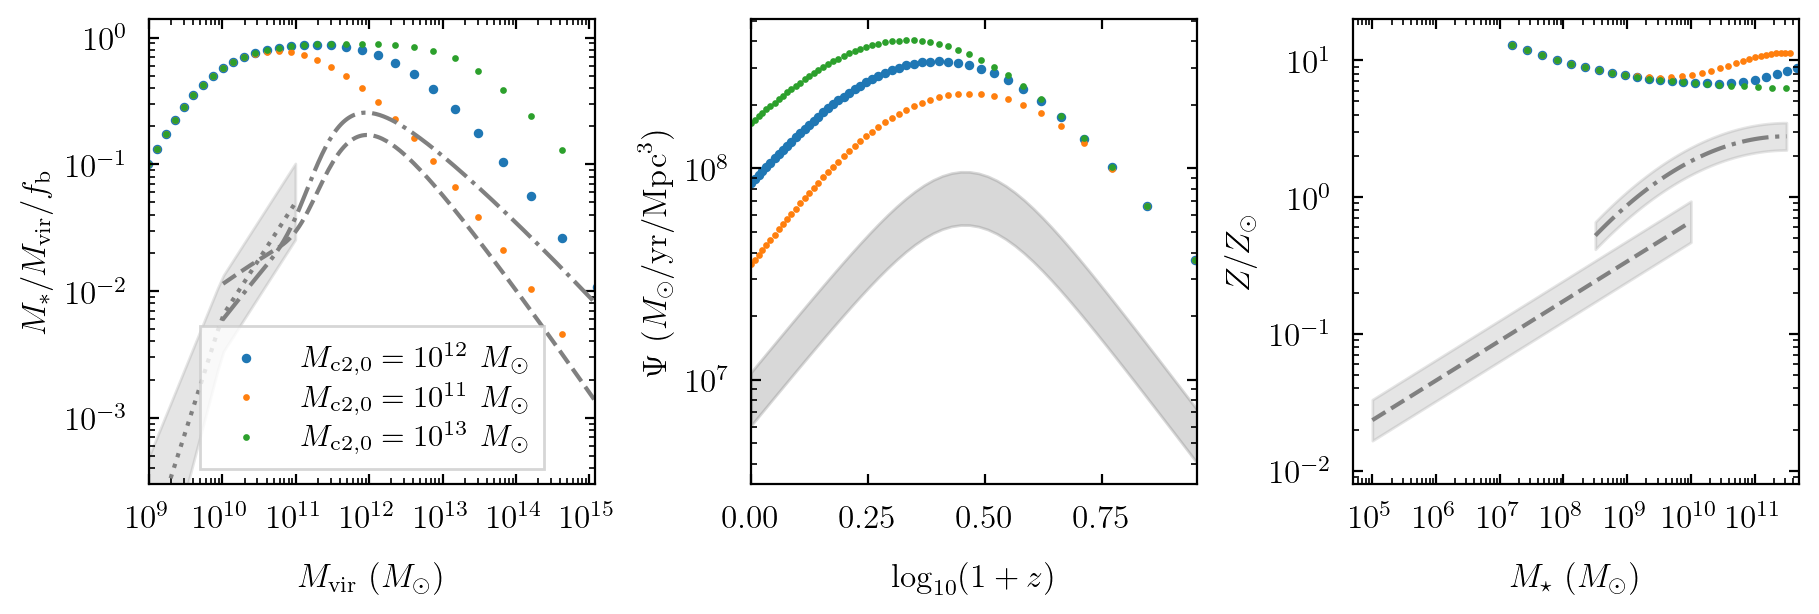

In [82]:
dic_mcooling_lo = evaluateModel(M_c2_0 = 1E11, **pars_cur)
dic_mcooling_hi = evaluateModel(M_c2_0 = 1E13, **pars_cur)
model_dics = [dic_cur, dic_mcooling_lo, dic_mcooling_hi]
labels = [r'$M_{\rm c2,0} = 10^{12}\ M_\odot$', r'$M_{\rm c2,0} = 10^{11}\ M_\odot$', 
          r'$M_{\rm c2,0} = 10^{13}\ M_\odot$']
plotModels(model_dics, labels, shmr_y_max = 1.4, mz_y_max = 2E1)

The mass where cooling becomes inefficient is clearly important for the high-mass end of the SHMR and mass-metallicity relations.

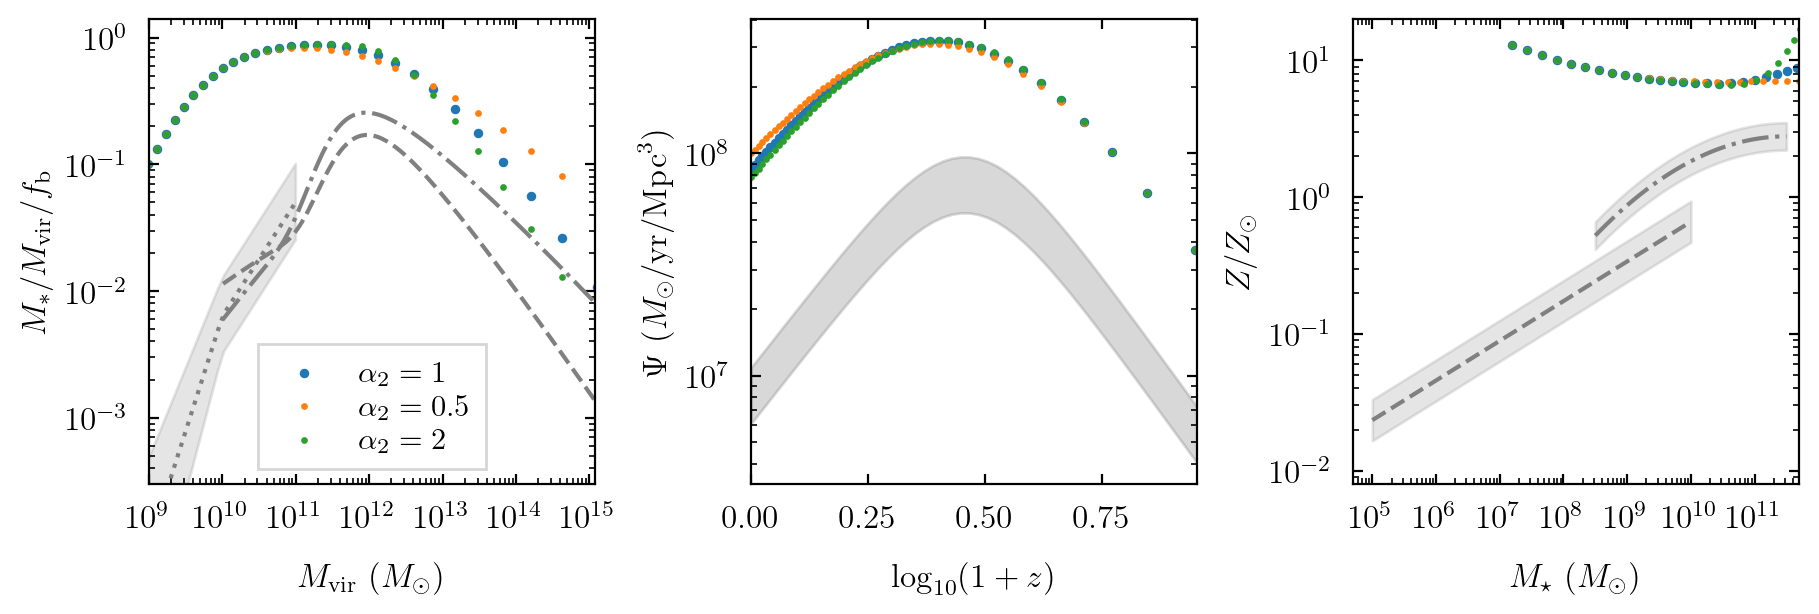

In [83]:
dic_alphacooling_lo = evaluateModel(alpha2 = 0.5, **pars_cur)
dic_alphacooling_hi = evaluateModel(alpha2 = 2.0, **pars_cur)
model_dics = [dic_cur, dic_alphacooling_lo, dic_alphacooling_hi]
labels = [r'$\alpha_2 = 1$', r'$\alpha_2 = 0.5$', r'$\alpha_2 = 2$']
plotModels(model_dics, labels, shmr_y_max = 1.4, mz_y_max = 2E1)

The $\alpha_2$ parameter does matter for the slope of the high-mass end of the SHMR and mass-metallicity relations.

#### Star formation law

We now add the losses due to the return of stellar material to the ISM.

In [84]:
del pars_cur['R_loss']
dic_cur = evaluateModel(**pars_cur)

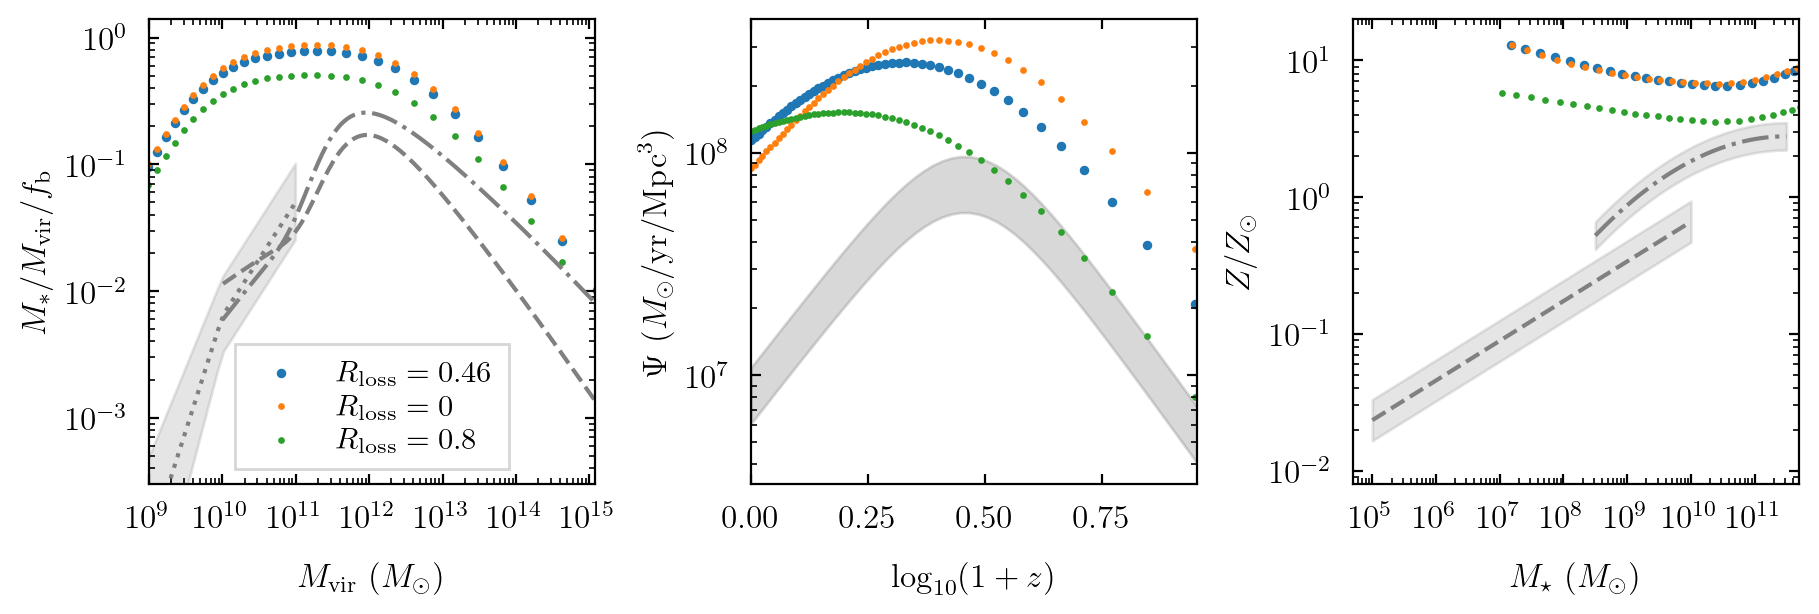

In [85]:
dic_rloss_lo = evaluateModel(R_loss = 0.0, **pars_cur)
dic_rloss_hi = evaluateModel(R_loss = 0.8, **pars_cur)
model_dics = [dic_cur, dic_rloss_lo, dic_rloss_hi]
labels = [r'$R_{\rm loss} = 0.46$', r'$R_{\rm loss} = 0$', r'$R_{\rm loss} = 0.8$']
plotModels(model_dics, labels, shmr_y_max = 1.4, mz_y_max = 2E1)

The return rate matters, but it is not really a free parameter given an IMF.

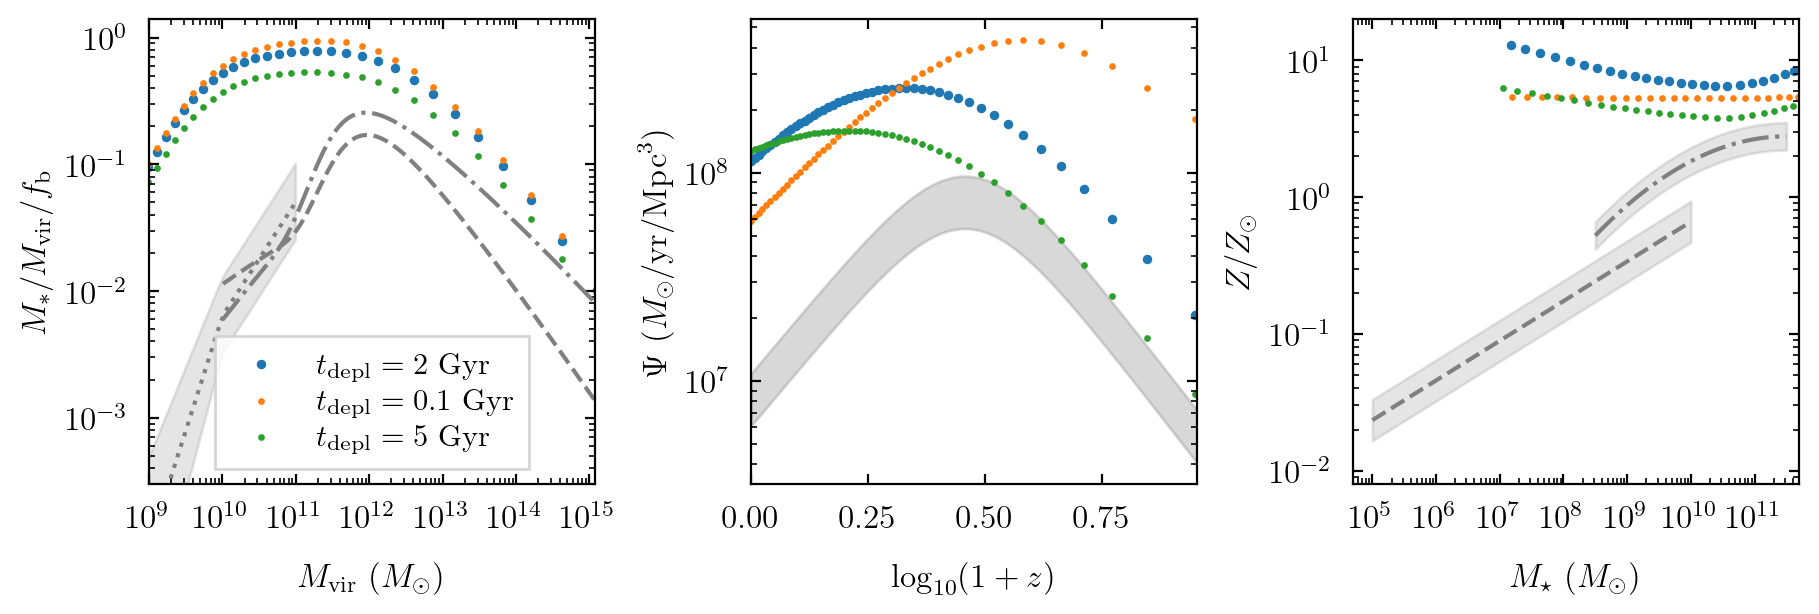

In [86]:
dic_tdepl_lo = evaluateModel(t_depl = 0.1, **pars_cur)
dic_tdepl_hi = evaluateModel(t_depl = 5.0, **pars_cur)
model_dics = [dic_cur, dic_tdepl_lo, dic_tdepl_hi]
labels = [r'$t_{\rm depl} = 2\ {\rm Gyr}$', r'$t_{\rm depl} = 0.1\ {\rm Gyr}$', 
          r'$t_{\rm depl} = 5\ {\rm Gyr}$']
plotModels(model_dics, labels, shmr_y_max = 1.4, mz_y_max = 2E1)

One would expect the depletion time to be extremely important, since it acts as the normalization of the SFR. While the global SFR of the Universe is indeed highly sensitive to $t_{\rm depl}$, the SHMR is barely sensitive to it at all. This highlights that the SFR may control how quickly stars are formed, but that the eventual stellar mass of galaxies is set by the amount of gas they can accrete and cool (as well as feedback, as we will see momentarily).

#### Feedback model

In [87]:
# We have now arrived at our fiducial model with no added parameters
del pars_cur['model_wind']
del pars_cur['eta_min']
dic_fid = evaluateModel(**pars_cur)
dic_cur = dic_fid

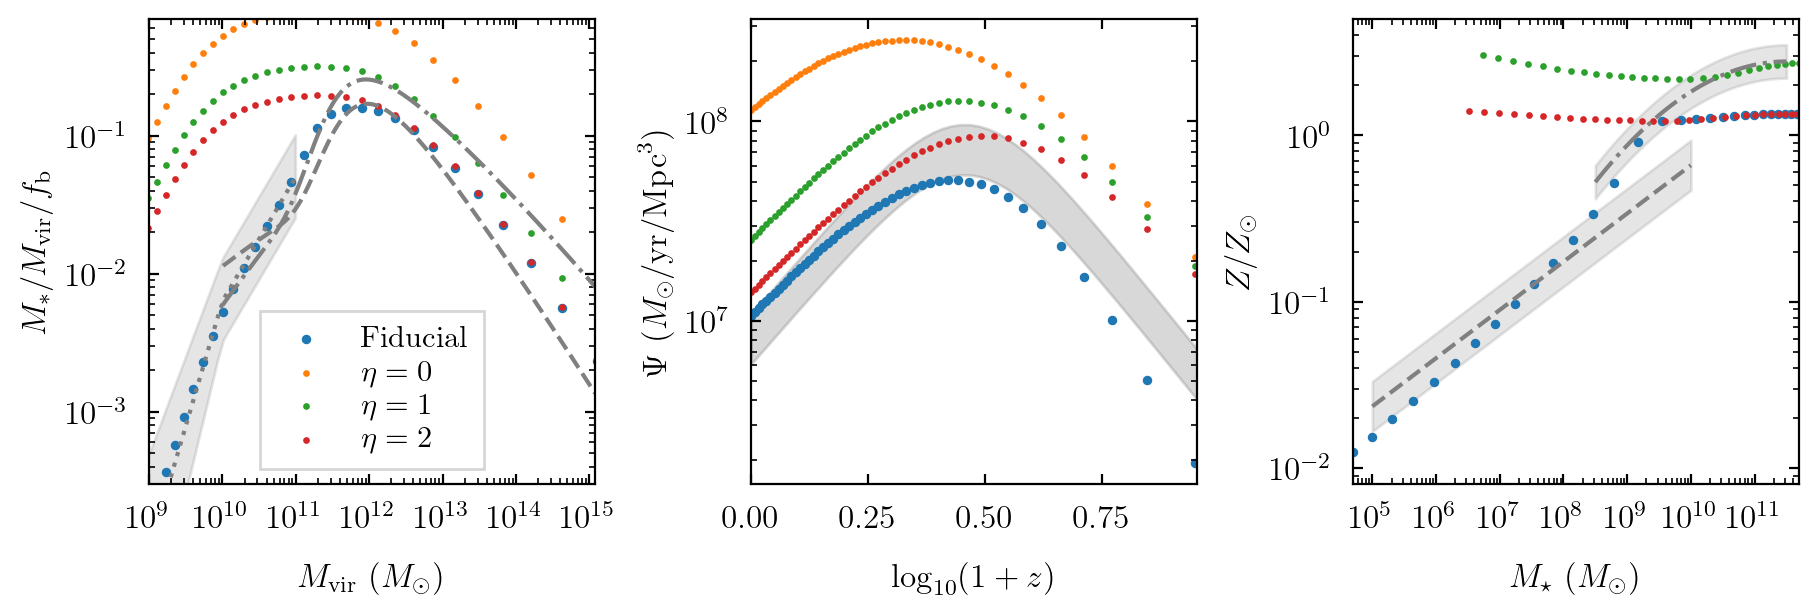

In [88]:
dic_wind_eta0 = evaluateModel(model_wind = 'fixed', eta_fixed = 0.0, eta_min = 0.0)
dic_wind_eta1 = evaluateModel(model_wind = 'fixed', eta_fixed = 1.0, eta_min = 0.0)
dic_wind_eta2 = evaluateModel(model_wind = 'fixed', eta_fixed = 2.0, eta_min = 0.0)

model_dics = [dic_cur, dic_wind_eta0, dic_wind_eta1, dic_wind_eta2]
labels = [r'$\mathrm{Fiducial}$', r'$\eta = 0$', r'$\eta = 1$', r'$\eta = 2$']
plotModels(model_dics, labels, save = save_plots, fn_out = 'sam_eta_fixed.pdf')

Clearly, constant mass loading factors cannot reproduce any of our observational constraints.

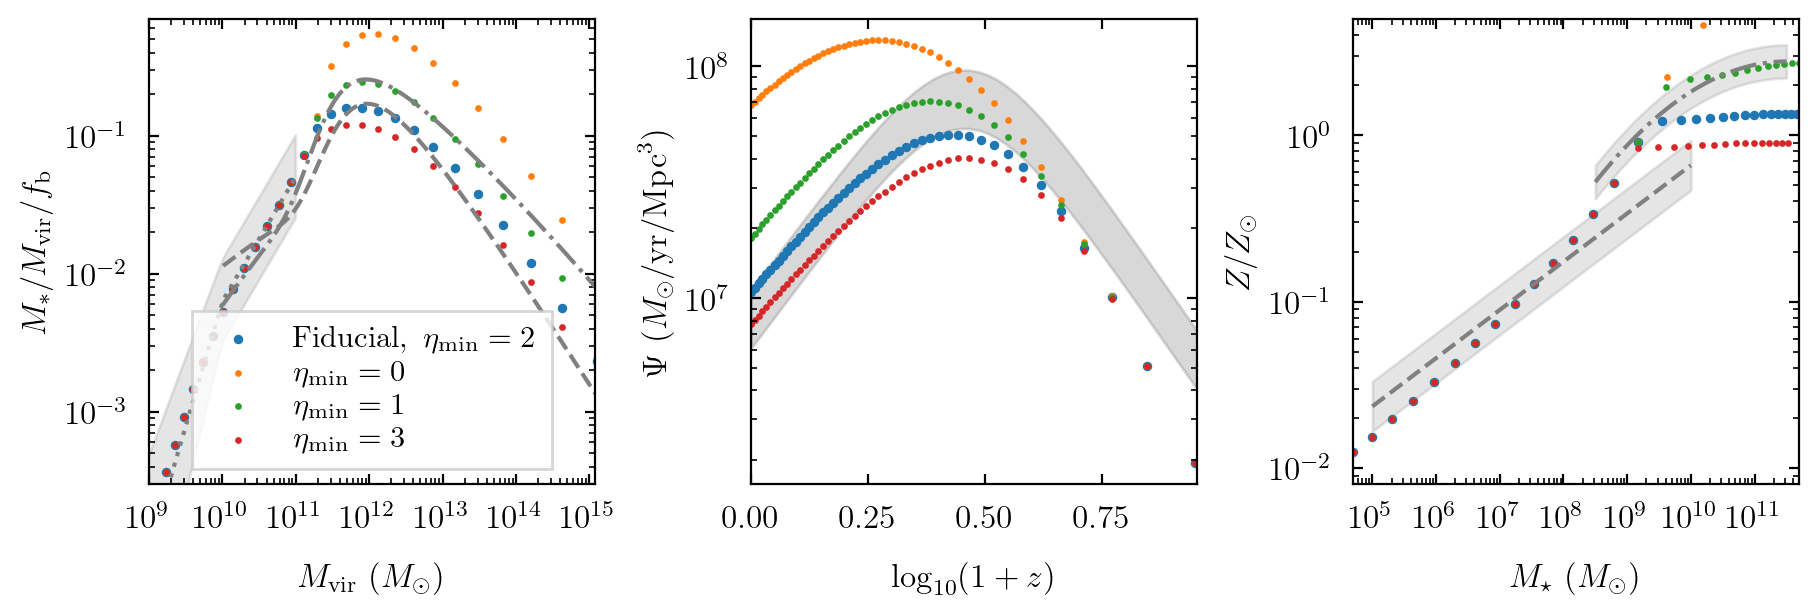

In [89]:
dic_wind_etamin0 = evaluateModel(eta_min = 0.0)
dic_wind_etamin1 = evaluateModel(eta_min = 1.0)
dic_wind_etamin3 = evaluateModel(eta_min = 3.0)

model_dics = [dic_cur, dic_wind_etamin0, dic_wind_etamin1, dic_wind_etamin3]
labels = [r'$\mathrm{Fiducial},\ \eta_{\rm min} = 2$', r'$\eta_{\rm min} = 0$', 
          r'$\eta_{\rm min} = 1$', r'$\eta_{\rm min} = 3$']
plotModels(model_dics, labels)

The minimum mass loading factor acts only at high masses, since our feedback model leads to $\eta \gg \eta_{\rm min}$ at low masses. No minimum feedback at all (orange) is hard to reconcile with any of the observations.

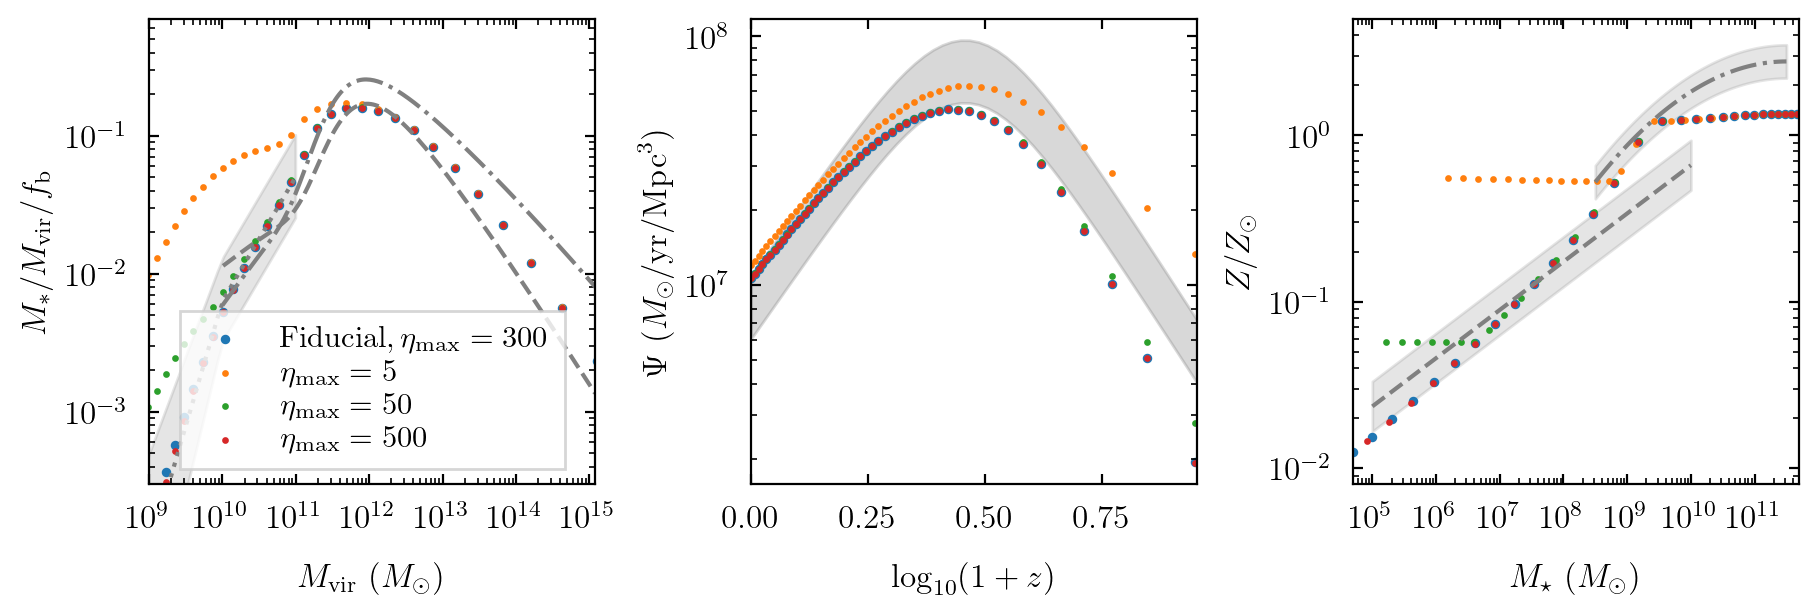

In [90]:
dic_wind_etamax0 = evaluateModel(eta_max = 5.0)
dic_wind_etamax1 = evaluateModel(eta_max = 50.0)
dic_wind_etamax2 = evaluateModel(eta_max = 500.0)

model_dics = [dic_cur, dic_wind_etamax0, dic_wind_etamax1, dic_wind_etamax2]
labels = [r'$\mathrm{Fiducial}, \eta_{\rm max} = 300$', r'$\eta_{\rm max} = 5$', 
          r'$\eta_{\rm max} = 50$', r'$\eta_{\rm max} = 500$']
plotModels(model_dics, labels, save = save_plots, fn_out = 'sam_eta_max.pdf')

Clearly, the extremely high values of $\eta$ are really needed to suppress star formation in low-mass halos!

### Model summary

In the plots above, we built our model component by component. As a final summary, let's see how the results change compared to the final model when we leave out critical components.

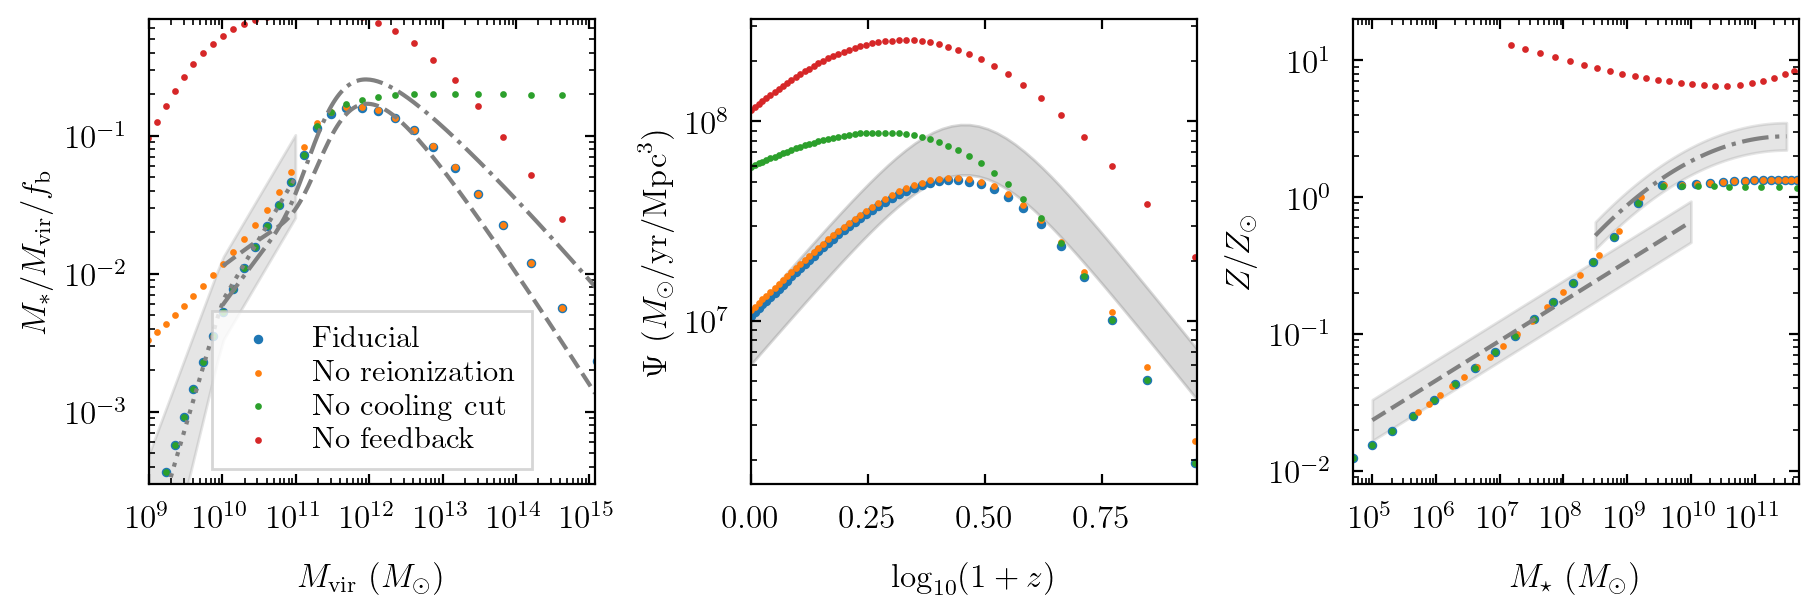

In [91]:
dic_no_reion = evaluateModel(model_reion = 'none')
dic_no_cool = evaluateModel(model_cooling = 'none')
dic_no_wind = evaluateModel(model_wind = 'none', eta_min = 0.0)

model_dics = [dic_cur, dic_no_reion, dic_no_cool, dic_no_wind]
labels = [r'$\mathrm{Fiducial}$', r'$\mathrm{No\ reionization}$', 
          r'$\mathrm{No\ cooling\ cut}$', r'$\mathrm{No\ feedback}$']
plotModels(model_dics, labels, save = save_plots, fn_out = 'sam_modelcomp.pdf', mz_y_max = 2E1)

### Saving results

For use in other notebooks, we save the results of our fiducial model to a pickle.

In [182]:
import pickle

fn = cmn.data_dir + 'tmp_files/fid_1000_04mean'
output_file = open(fn, 'wb')
pickle.dump(dic_fid, output_file)
output_file.close()

In [78]:
fn = cmn.data_dir + 'tmp_files/wech_10000_3to6init'
output_file = open(fn, 'wb')
pickle.dump(dic_wech, output_file)
output_file.close()

In [162]:
fn = cmn.data_dir + 'tmp_files/wechhi_800_-6to6init'
output_file = open(fn, 'wb')
pickle.dump(dic_wech_hi, output_file)
output_file.close()

fn = cmn.data_dir + 'tmp_files/wechlo_800_-6to6init'
output_file = open(fn, 'wb')
pickle.dump(dic_wech_lo, output_file)
output_file.close()

fn = cmn.data_dir + 'tmp_files/wechmean_800_-6to6init'
output_file = open(fn, 'wb')
pickle.dump(dic_wech_mean, output_file)
output_file.close()